In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)
pd.options.display.float_format = '{:,.2f}'.format

from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

from yellowbrick.cluster import KElbowVisualizer
from sklearn import cluster

In [4]:
df = pd.read_csv('data/df_for_clustering.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [5]:
print("Número de registros: {}".format(df.pk_cid.count())) #5713411
print("Número de ids únicos: {}".format(df.pk_cid.nunique())) #455515
print("Número de particiones únicos: {}".format(df.pk_partition.nunique())) #17

Número de registros: 442995
Número de ids únicos: 442995
Número de particiones únicos: 1


In [6]:
# Quitamos a los fallecidos:
df = df[df["deceased"]=='N']

In [7]:
df.shape

(442909, 36)

In [8]:
df_raw = df.copy()

# 1. Features Analysis and Transformation before Clustering

In [9]:
# columnas que borramos de partida:
df.drop(columns=['entry_date','z_segment_mode'], inplace=True)

## Global functions

### Correlations

In [10]:
def matriz_correlacion_numeric_features(df):
    numeric_df = df.select_dtypes(include=['number'])

    correlation_matrix = numeric_df.corr(method='pearson')

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación (Pearson)')
    plt.show()

In [11]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0 
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [12]:
def matriz_correlacion_object_features(dfg,listdf):
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Processing

In [13]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [14]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [15]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [16]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

----------------------------------------------------------

In [17]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])

In [18]:
filtered_stats_categoricas = stats_df[(stats_df['type'] != 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
17,em_account_pp,1,0.00,100.00,int64
29,z_churn_customer_flag,1,0.00,100.00,int64
11,short_term_deposit,2,0.00,100.00,int64
24,em_account_p,2,0.00,100.00,int64
13,mortgage,2,0.00,99.99,int64
12,loans,2,0.00,99.99,int64
14,funds,2,0.00,99.70,int64
15,securities,2,0.00,99.60,int64
30,z_new_customer_flag,2,0.00,99.01,int64
28,z_partition_segment_changed,2,0.00,98.92,int64


In [19]:
filtered_stats_categoricas = stats_df[(stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
1,pk_partition,1,0.00,100.00,object
9,deceased,1,0.00,100.00,object
5,country_id,41,0.00,99.96,object
4,segment,3,0.00,65.22,object
7,gender,2,0.00,51.40,object
2,entry_channel,65,0.00,44.98,object


Decisiones:
- Borramos "deceased" por tener el 99% de los registros con el mismo valor
- Borramos "country_id" por tener el 99% de los registros con el mismo. Dejamos el region_code que está relleno cuando el pais es España y hay mas variabilidad.
- "segment" y "gender" OHE 
- "entry_channel" agrupar y luego OHE

In [20]:
df.drop(columns=['deceased','country_id'], inplace=True)

### 1.0 Correlations

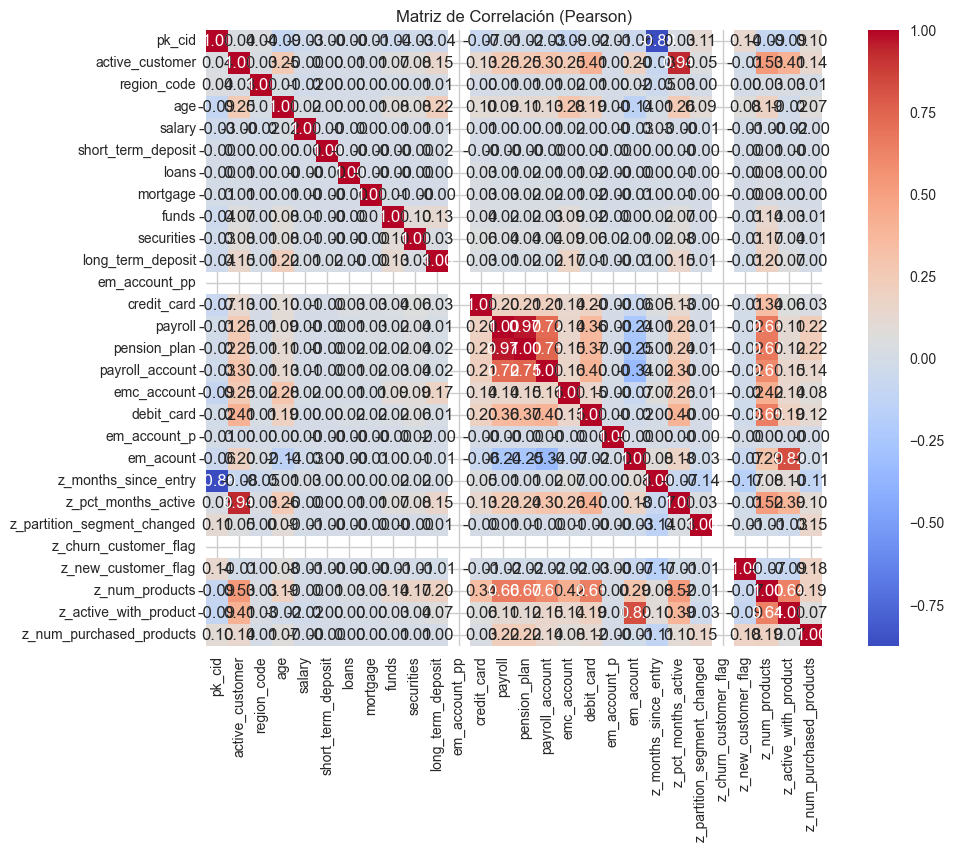

In [21]:
matriz_correlacion_numeric_features(df)

In [22]:
df.em_acount.value_counts(normalize=True)

em_acount
1   0.67
0   0.33
Name: proportion, dtype: float64

In [23]:
# Borramos "z_pct_months_active" por estar al 90% correlada con "active_customer" y "payroll_account" porque es igual que "payroll"
df.drop(columns=['z_pct_months_active', 'payroll_account'], inplace=True)

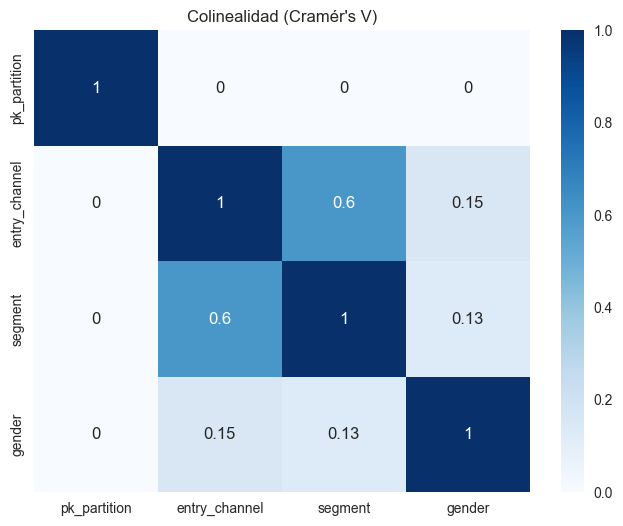

In [24]:
object_cols= df.select_dtypes(exclude=['number']).columns
matriz_correlacion_object_features(df, object_cols)

### 1.2 Encoding

In [25]:
df = group_minor_categories(df, 'entry_channel', 0.01)
df.drop(columns='entry_channel', inplace=True)

df.rename(columns={'entry_channel_grouped':'entry_channel'}, inplace=True)

In [26]:
# df = group_minor_categories(df, 'region_code', 0.005)
# df.drop(columns='region_code', inplace=True)

Mejor no agrupamos la región y le hacemos el Frequency Encoding que consideramos que nos va a aportar más información.

In [27]:
# Frequency Encoding:
freqenc_cols = ['region_code']
df = frequency_encode(df, freqenc_cols)

In [28]:
# One Hot Encoding:
ohe_cols = ['entry_channel','segment','gender']
df = one_hot_encode(df, ohe_cols)

### 1.3 Normalization

In [29]:
normalize_cols = ['age','salary','z_months_since_entry','z_num_products','z_num_purchased_products']

df = normalize_features(df, normalize_cols)

# 2. Clustering

In [30]:
print(df.shape)

(442909, 43)


## K-means

In [31]:
clustering_features = df.drop(columns=['pk_cid', 'pk_partition']).columns
clustering_features


Index(['active_customer', 'age', 'salary', 'short_term_deposit', 'loans',
       'mortgage', 'funds', 'securities', 'long_term_deposit', 'em_account_pp',
       'credit_card', 'payroll', 'pension_plan', 'emc_account', 'debit_card',
       'em_account_p', 'em_acount', 'z_months_since_entry',
       'z_partition_segment_changed', 'z_churn_customer_flag',
       'z_new_customer_flag', 'z_num_products', 'z_active_with_product',
       'z_num_purchased_products', 'region_code_freq', 'entry_channel_KAT',
       'entry_channel_KFA', 'entry_channel_KFC', 'entry_channel_KHD',
       'entry_channel_KHE', 'entry_channel_KHK', 'entry_channel_KHM',
       'entry_channel_KHN', 'entry_channel_KHQ', 'entry_channel_Other',
       'entry_channel_RED', 'segment_01 - TOP', 'segment_02 - PARTICULARES',
       'segment_03 - UNIVERSITARIO', 'gender_H', 'gender_V'],
      dtype='object')

### PCA 1

In [32]:
from sklearn import decomposition

X = df[clustering_features]

pca = decomposition.PCA(0.9)
pca.fit(X)
x_pca = pd.DataFrame(
    pca.transform(X), columns=[f"PC{i}" for i in range(2, pca.n_components_ + 2)]
)
pca.n_components_, pca.explained_variance_ratio_.sum()

(11, 0.9100450090877326)

In [33]:
pd.DataFrame(pca.components_, columns=clustering_features)

,active_customer,age,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,entry_channel_RED,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V
0,0.24,0.09,0.00,0.00,0.00,0.00,0.00,0.01,0.02,-0.00,0.02,0.05,0.06,0.08,0.12,0.00,-0.18,-0.05,0.02,-0.00,-0.01,0.03,-0.08,0.00,0.01,0.06,0.01,0.21,-0.00,-0.42,0.05,0.09,0.05,-0.07,0.01,0.01,0.02,0.49,-0.51,-0.25,0.25
1,0.06,0.03,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02,0.02,0.04,0.00,-0.13,-0.03,0.01,0.00,-0.01,0.00,-0.08,0.00,0.01,0.03,0.01,0.06,0.00,-0.17,0.01,0.03,0.02,0.00,0.01,-0.00,0.00,0.18,-0.18,0.66,-0.66
2,-0.50,-0.01,0.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.02,-0.00,-0.01,-0.03,-0.03,-0.06,-0.14,-0.00,-0.58,-0.03,0.00,-0.00,0.01,-0.10,-0.61,-0.01,0.02,-0.02,-0.01,0.02,0.00,0.01,0.00,-0.02,-0.02,0.04,-0.00,-0.01,-0.02,-0.02,0.04,-0.06,0.06
3,0.04,-0.05,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01,-0.02,-0.02,-0.03,-0.04,-0.00,0.05,-0.36,0.00,-0.00,-0.00,-0.01,0.01,0.00,0.00,-0.01,-0.00,-0.12,0.01,-0.58,0.00,0.03,0.01,0.66,0.00,0.00,0.01,-0.19,0.19,-0.02,0.02
4,0.60,-0.04,0.00,-0.00,0.00,0.00,0.00,0.01,0.02,0.00,0.04,0.24,0.25,0.08,0.31,0.00,-0.48,-0.01,-0.01,-0.00,0.02,0.09,-0.14,0.01,0.02,0.01,0.01,-0.07,-0.00,0.10,-0.01,-0.02,-0.00,-0.04,0.00,0.02,0.04,-0.28,0.24,-0.01,0.01
5,-0.11,-0.03,0.00,0.00,0.00,0.00,0.01,0.01,0.01,0.00,0.03,0.07,0.07,0.12,0.09,0.00,-0.00,0.37,-0.06,0.00,-0.03,0.05,0.09,-0.01,-0.00,-0.06,-0.01,0.73,0.02,-0.16,-0.10,-0.40,-0.13,0.15,-0.02,-0.02,0.00,-0.13,0.13,0.00,-0.00
6,-0.53,0.01,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.03,-0.00,0.06,0.37,0.38,0.07,0.45,-0.00,-0.06,0.00,-0.01,0.00,-0.02,0.18,0.29,0.01,-0.01,0.18,0.00,-0.25,0.00,-0.05,0.04,0.00,0.02,0.03,0.01,0.02,-0.03,0.06,-0.03,-0.00,0.00
7,0.07,0.04,0.00,0.00,-0.00,-0.00,0.01,0.01,0.06,-0.00,0.01,-0.11,-0.11,0.23,-0.20,0.00,-0.03,0.30,-0.03,-0.00,-0.02,-0.02,-0.04,-0.01,0.02,0.72,0.03,-0.31,0.04,-0.16,0.03,-0.35,-0.01,-0.02,0.02,-0.00,0.08,-0.06,-0.02,-0.01,0.01
8,-0.08,0.04,0.00,0.00,-0.00,0.00,0.02,0.01,0.11,0.00,0.01,0.16,0.17,0.53,-0.50,0.00,-0.12,-0.01,0.03,-0.00,-0.01,0.06,0.20,0.02,0.01,-0.06,0.02,0.09,0.02,-0.10,-0.14,0.44,-0.10,-0.14,0.00,-0.02,0.18,-0.19,0.00,0.00,-0.00
9,-0.06,-0.03,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.03,-0.00,-0.00,-0.22,-0.22,-0.08,0.43,0.00,0.10,0.14,0.00,0.00,-0.02,-0.02,-0.14,-0.01,0.00,0.28,-0.03,0.11,0.06,-0.20,-0.23,0.55,-0.31,-0.18,-0.02,-0.02,-0.01,-0.14,0.15,0.00,-0.00


In [34]:
# Crea un DataFrame con las cargas de cada variable en cada componente
loadings = pd.DataFrame(
    pca.components_,
    columns=clustering_features,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Visualiza los 5 valores más altos (positivos o negativos) para cada PC
for i, row in loadings.iterrows():
    print(f"\n{i} - Top features:")
    print(row.abs().sort_values(ascending=False).head(5))


PC1 - Top features:
segment_03 - UNIVERSITARIO   0.51
segment_02 - PARTICULARES    0.49
entry_channel_KHE            0.42
gender_H                     0.25
gender_V                     0.25
Name: PC1, dtype: float64

PC2 - Top features:
gender_H                     0.66
gender_V                     0.66
segment_03 - UNIVERSITARIO   0.18
segment_02 - PARTICULARES    0.18
entry_channel_KHE            0.17
Name: PC2, dtype: float64

PC3 - Top features:
z_active_with_product   0.61
em_acount               0.58
active_customer         0.50
debit_card              0.14
z_num_products          0.10
Name: PC3, dtype: float64

PC4 - Top features:
entry_channel_KHQ            0.66
entry_channel_KHE            0.58
z_months_since_entry         0.36
segment_02 - PARTICULARES    0.19
segment_03 - UNIVERSITARIO   0.19
Name: PC4, dtype: float64

PC5 - Top features:
active_customer             0.60
em_acount                   0.48
debit_card                  0.31
segment_02 - PARTICULARES   0.28
pens

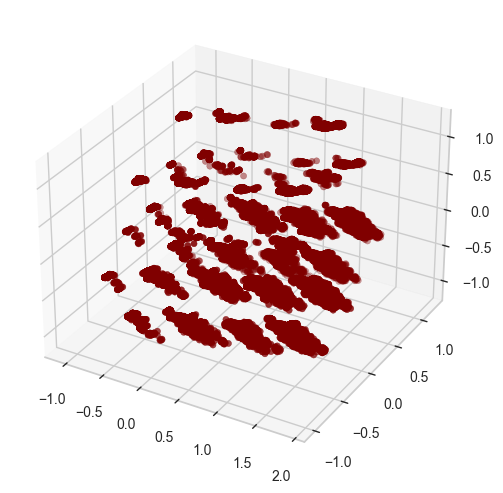

In [35]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xs=x_pca.iloc[:, 0],
    ys=x_pca.iloc[:, 1],
    zs=x_pca.iloc[:, 2],
    c="maroon",
    marker="o",
)
plt.show()

### 1. Kmeans Clustering

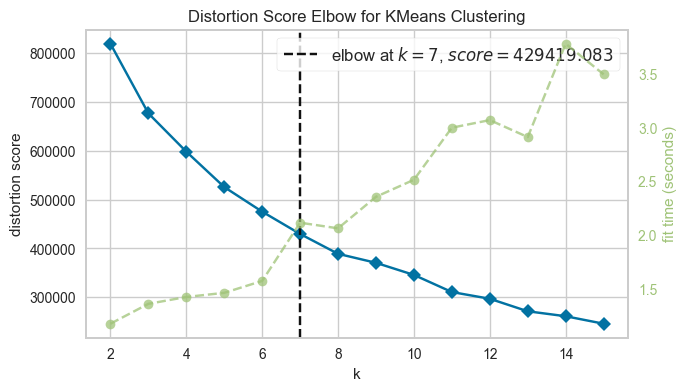

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
Elbow_M = KElbowVisualizer(cluster.KMeans(n_init=10), k=15, ax=ax)
Elbow_M.fit(x_pca)
Elbow_M.show()
plt.show()

In [52]:
# kmeans = cluster.KMeans(n_clusters=Elbow_M.elbow_value_, n_init=10)
kmeans = cluster.KMeans(n_clusters=5, n_init=10)
kmeans.fit(x_pca)
clusters = kmeans.predict(x_pca) + 1

In [53]:
# Guardar modelos entrenados
import joblib

joblib.dump(pca, 'models/pca_model.pkl')
joblib.dump(kmeans, 'models/kmeans_model.pkl')

['models/kmeans_model.pkl']

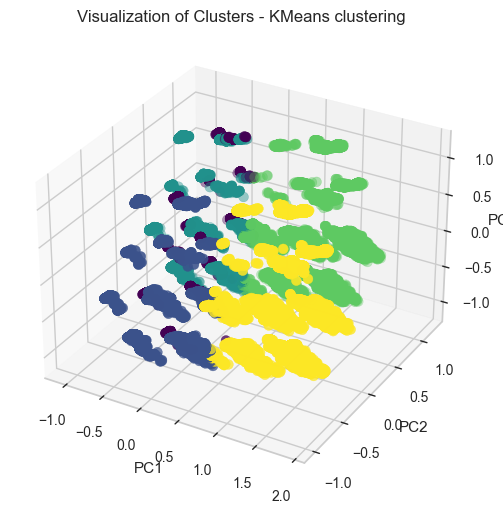

In [54]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xs=x_pca.iloc[:, 0],
    ys=x_pca.iloc[:, 1],
    zs=x_pca.iloc[:, 2],
    marker="o",
    c=clusters,
    s=50,
    cmap="viridis",
)
ax.set(
    xlabel="PC1",
    ylabel="PC2",
    zlabel="PC3",
    title="Visualization of Clusters - KMeans clustering",
)
plt.show()

In [55]:
df["cluster"] = kmeans.predict(x_pca) + 1

In [56]:
df["cluster"].value_counts().sort_index()

cluster
1     73236
2     93842
3    118736
4     67253
5     89842
Name: count, dtype: int64

In [57]:
# cluster_descriptions = {
#     1: "Cluster IBAN Power",
#     2: "Cluster Silencioso",
#     3: "Cluster Traditional Power",
#     4: "Cluster Digital Pro",
#     5: "Cluster Reactivacion"
# }

# for cluster_id, description in cluster_descriptions.items():
#     df.loc[df["cluster"] == cluster_id, "cluster_description"] = description


In [58]:
df

,pk_cid,pk_partition,active_customer,age,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,entry_channel_RED,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,cluster
0,1000028,2019-05-01,1.00,0.41,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,1,0,1,0.53,0,0,0,0.22,1,0.00,0.21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,1.00,0.00,4
1,1000096,2019-05-01,1.00,0.08,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,1.00,0,0,0,0.00,0,0.00,0.21,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,4
2,1000113,2019-05-01,0.00,0.50,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0.94,0,0,0,0.00,0,0.00,0.01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,5
3,1000130,2019-05-01,1.00,0.41,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0.26,0,0,0,0.00,0,0.00,0.21,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,4
4,1000157,2019-05-01,1.00,0.41,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,0.74,0,0,0,0.11,1,0.00,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442990,998859,2019-05-01,1.00,0.41,0.00,0,0,0,0,0,0,0,1,1.00,1.00,1,1,0,0,0.92,0,0,0,0.67,1,0.00,0.21,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,5
442991,999706,2019-05-01,0.00,0.12,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0.09,0,0,0,0.00,0,0.00,0.21,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,4
442992,999825,2019-05-01,1.00,0.37,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,1,0.53,0,0,0,0.11,1,0.00,0.01,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,5
442993,999835,2019-05-01,1.00,0.29,0.00,0,0,0,1,0,0,0,0,0.00,0.00,0,0,0,0,0.75,0,0,0,0.11,1,0.00,0.10,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,4


### - Interpretation

Unimos el dataframe original (con el sin procesar) para saber interpretar bien los clusters con cada variable antes de la estandarización + otras variables agrupadas que he creado.

In [59]:
new_cols = [col for col in df.columns if col not in df_raw.columns] # todas las columnas que no esten en df_input_original_cols, es decir, o transformaciones o agrupamientos
df_merged = pd.merge(df_raw, df[new_cols], left_index=True, right_index=True)

In [60]:
interpretation_cols = ['entry_date', 'entry_channel',
       'active_customer', 'segment', 'country_id', 'region_code', 'gender',
       'age', 'deceased', 'salary', 'short_term_deposit', 'loans', 'mortgage',
       'funds', 'securities', 'long_term_deposit', 'em_account_pp',
       'credit_card', 'payroll', 'pension_plan', 'payroll_account',
       'emc_account', 'debit_card', 'em_account_p', 'em_acount',
       'z_months_since_entry', 'z_pct_months_active',
       'z_partition_segment_changed', 'z_segment_mode',
       'z_churn_customer_flag', 'z_new_customer_flag', 'z_num_products',
       'z_active_with_product', 'z_num_purchased_products', 
       'cluster']

In [61]:
# for col in df_merged[interpretation_cols].columns:
#     if df_merged[col].nunique() == 2 and set(df_merged[col].dropna().unique()).issubset({0, 1}):
#         df_merged[col] = df_merged[col].map({1: 'SI', 0: 'NO'})

In [62]:
df_merged[interpretation_cols]

,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,cluster
0,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"133,378.89",0,0,0,0,0,0,0,0,0.00,0.00,0,0,1,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,4
1,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,10,N,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,53.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,4
2,2015-04-01,KAT,0.00,02 - PARTICULARES,ES,14.00,V,54,N,"136,705.50",0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,50.00,0.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,5
3,2018-03-01,KAT,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"126,133.50",0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,14.00,0.27,0,02 - PARTICULARES,0,0,0.00,0,0.00,4
4,2016-03-01,KFC,1.00,02 - PARTICULARES,ES,46.00,V,44,N,"68,038.20",0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,1,39.00,0.94,0,02 - PARTICULARES,0,0,1.00,1,0.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442990,2015-05-01,KFC,1.00,02 - PARTICULARES,ES,28.00,V,44,N,"126,242.40",0,0,0,0,0,0,0,1,1.00,1.00,1,1,1,0,0,49.00,1.00,0,02 - PARTICULARES,0,0,6.00,1,0.00,5
442991,2018-12-01,KFC,0.00,02 - PARTICULARES,ES,28.00,H,14,N,0.00,0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,5.00,0.17,0,02 - PARTICULARES,0,0,0.00,0,0.00,4
442992,2017-01-01,KFC,1.00,02 - PARTICULARES,ES,48.00,V,40,N,"108,659.43",0,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,5
442993,2016-02-01,KAT,1.00,02 - PARTICULARES,ES,8.00,H,32,N,"111,945.96",0,0,0,1,0,0,0,0,0.00,0.00,0,0,0,0,0,40.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,4


In [63]:
df_merged.dtypes

pk_cid                           int64
pk_partition                    object
entry_date                      object
entry_channel                   object
active_customer                float64
segment                         object
country_id                      object
region_code                    float64
gender                          object
age                              int64
deceased                        object
salary                         float64
short_term_deposit               int64
loans                            int64
mortgage                         int64
funds                            int64
securities                       int64
long_term_deposit                int64
em_account_pp                    int64
credit_card                      int64
payroll                        float64
pension_plan                   float64
payroll_account                  int64
emc_account                      int64
debit_card                       int64
em_account_p             

In [64]:
categorical_features = df_merged[interpretation_cols].select_dtypes(include=["object", "category"]).columns

summary_dict = {}
for col in categorical_features:
    summary_dict[col] = df_merged.groupby('cluster')[col].agg(
        count='count',
        n_unique=pd.Series.nunique,
        top=lambda x: x.mode()[0] if not x.mode().empty else None,
        freq=lambda x: x.value_counts().iloc[0] if not x.empty else 0
    )

df_categorical_summary = pd.concat(summary_dict, axis=1)
df_categorical_summary.T.style.background_gradient(cmap='Blues', axis=1)

* Representación variables numéricas

In [65]:
numeric_features = df_merged[interpretation_cols].select_dtypes(include=["number"]).columns

In [66]:
df_merged[numeric_features].groupby('cluster').agg(['count','max','min','mean','median']).T.style.background_gradient(cmap='Reds', axis=1)

In [91]:
styled_df = df_merged[numeric_features].groupby('cluster').agg(['mean', 'median']).style.background_gradient(cmap='Reds', axis=0)
styled_df.to_excel('tabla_numeric_cols_clusters.xlsx', engine='openpyxl')

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

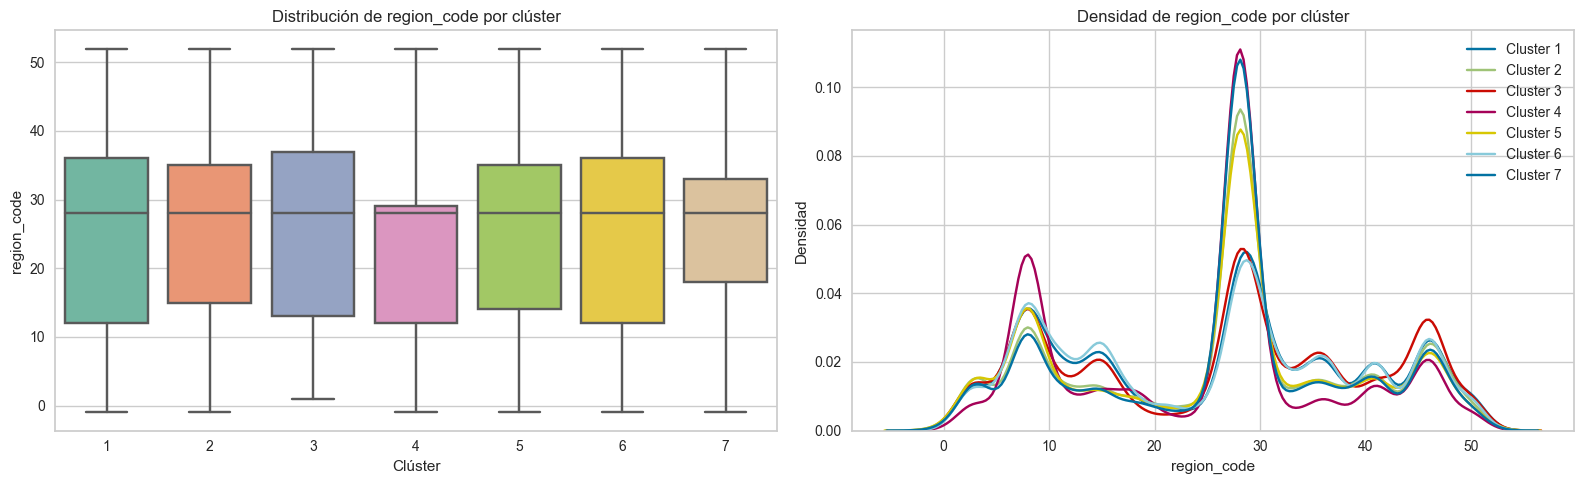

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

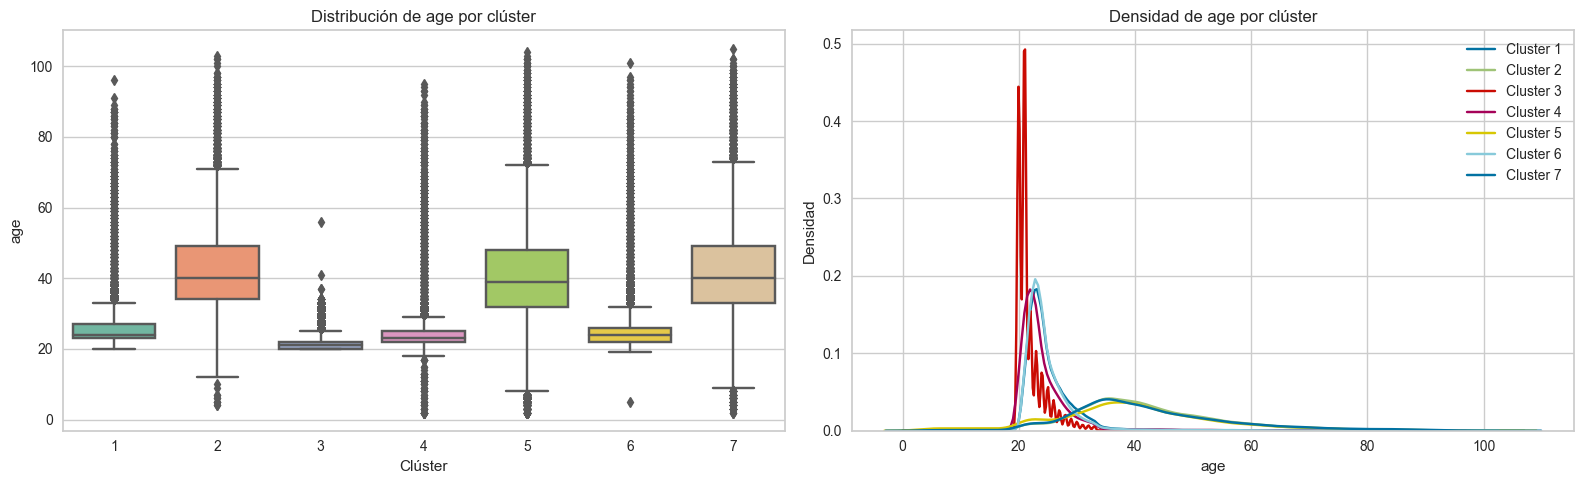

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

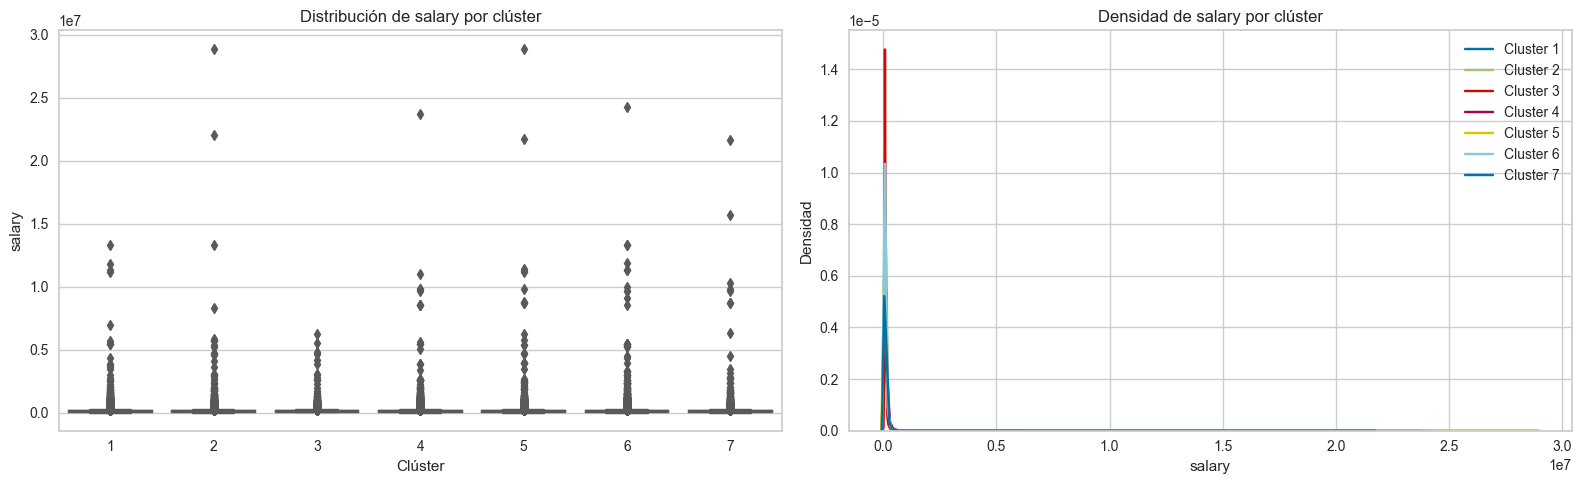

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/248344501.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/248344501.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdepl

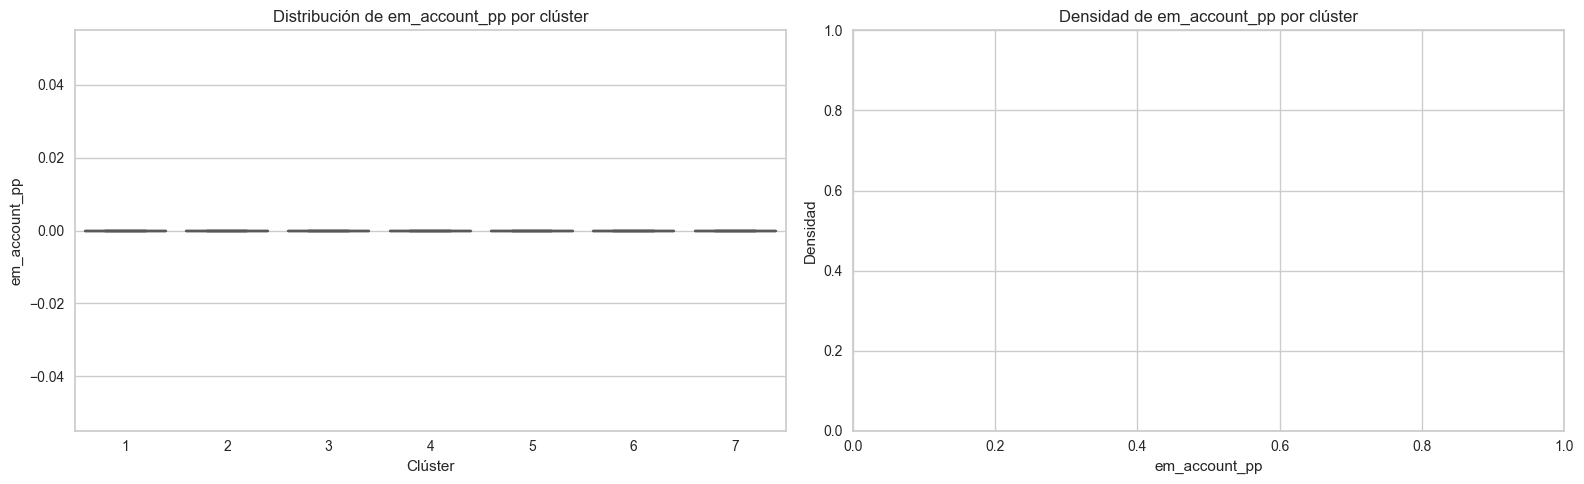

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

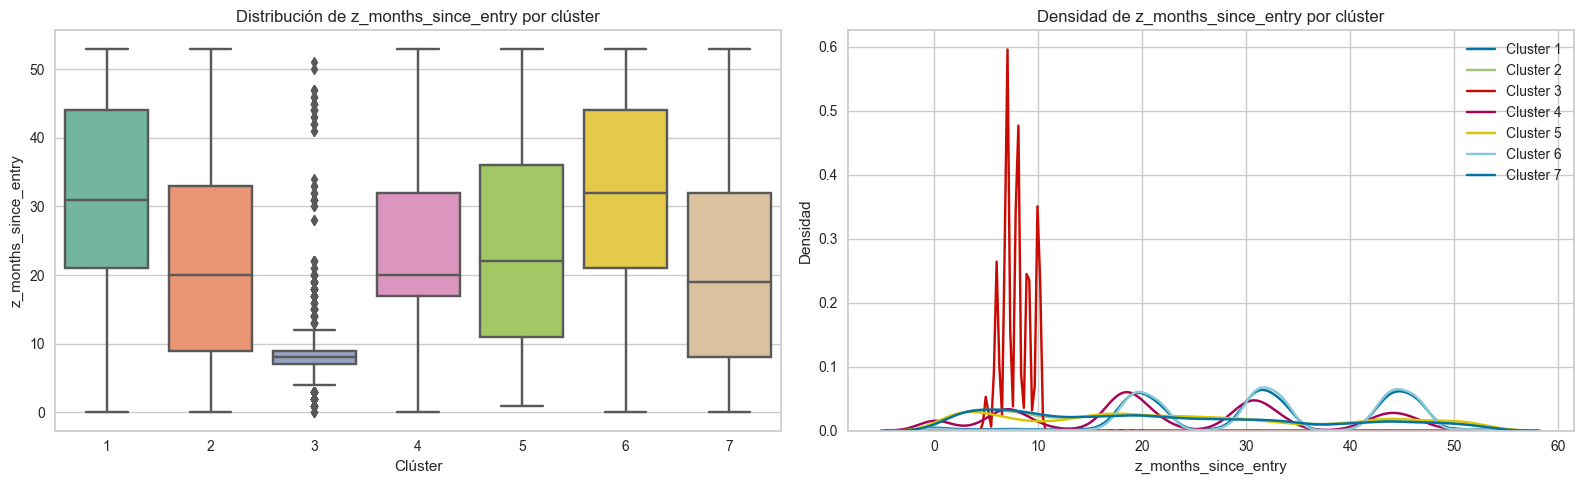

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

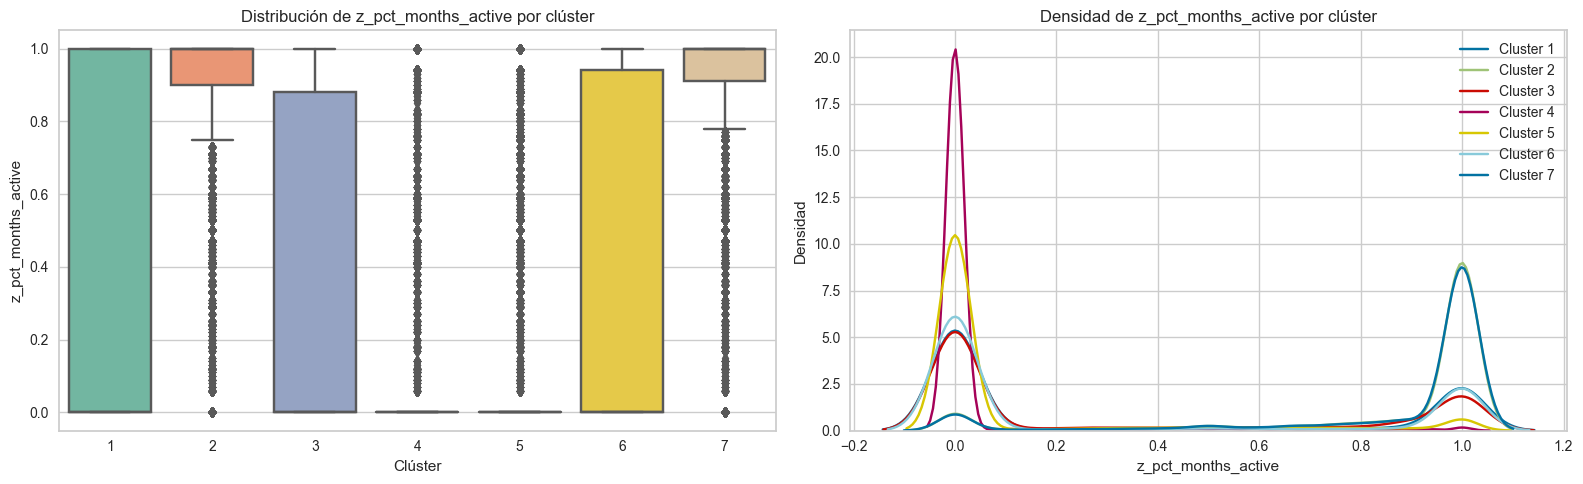

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/248344501.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/248344501.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdepl

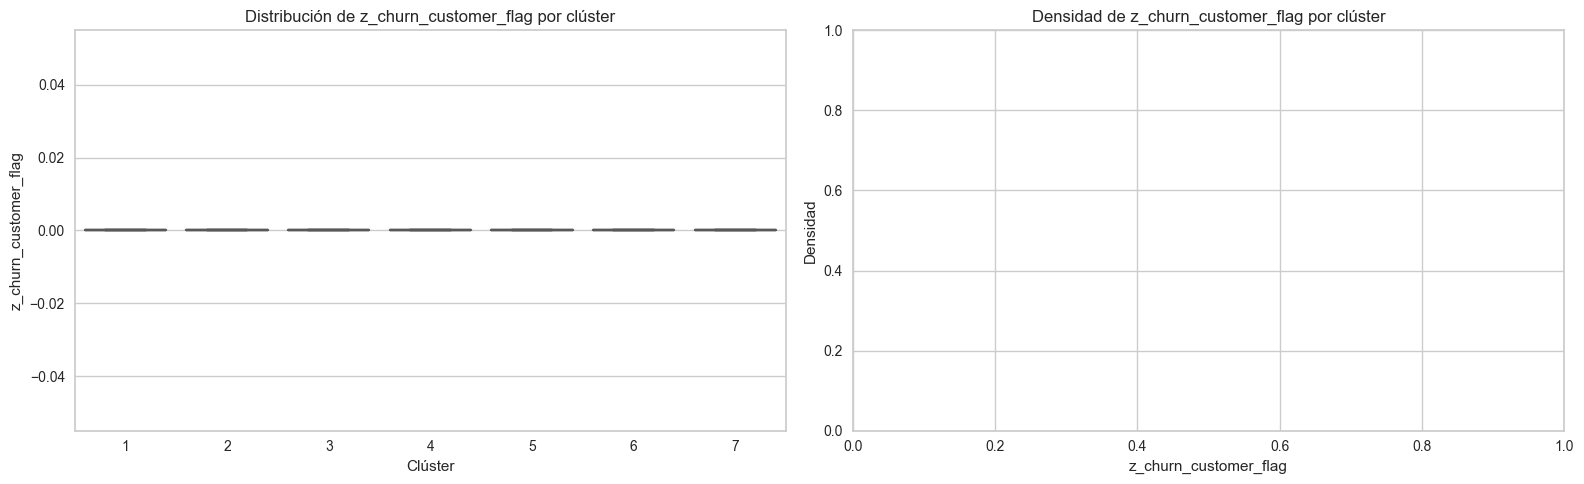

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

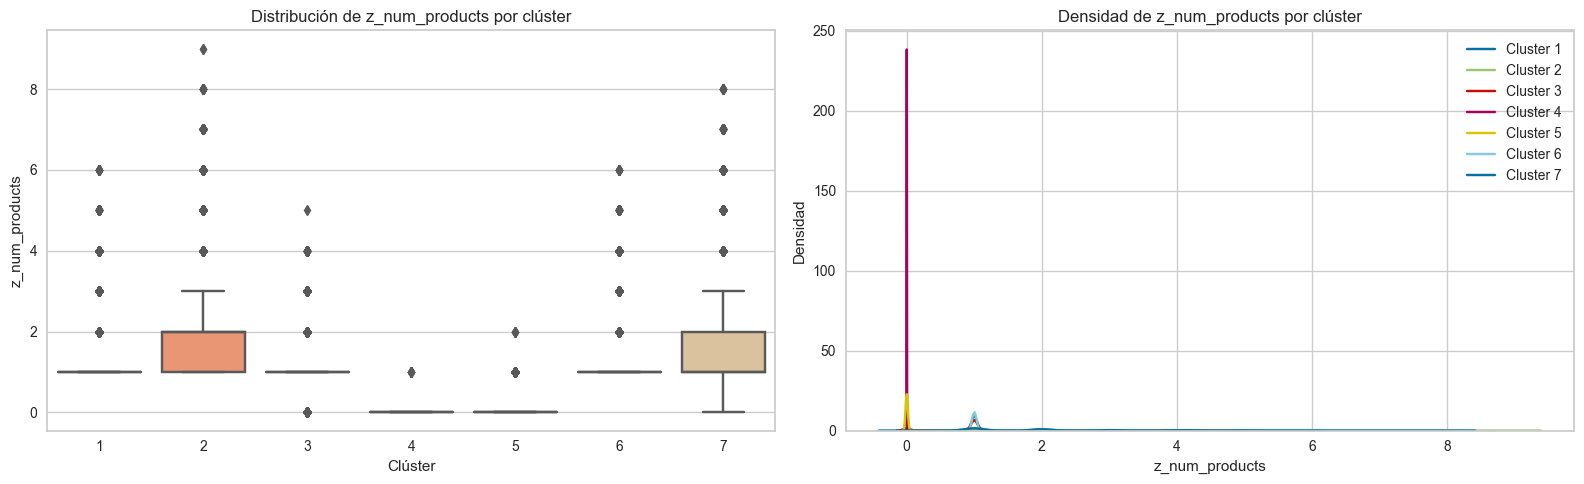

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

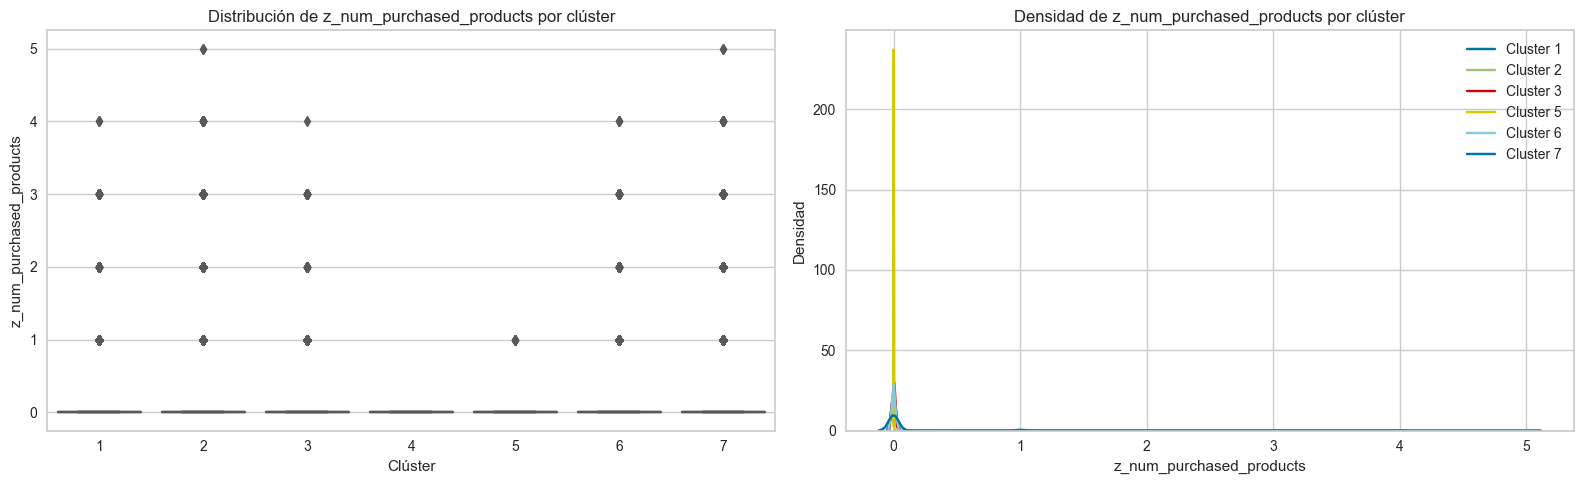

/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/248344501.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/248344501.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdepl

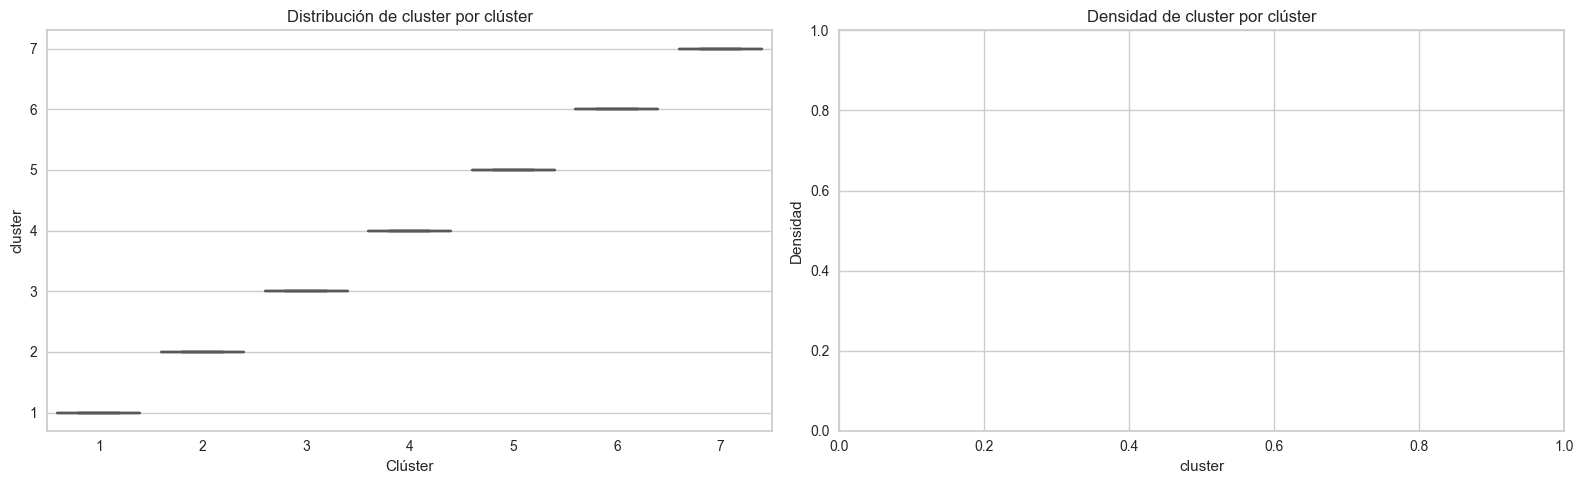

In [92]:
for col in numeric_features:
    unique_vals = sorted(df_merged[col].dropna().unique())
    is_flag = len(unique_vals) == 2 and set(unique_vals).issubset({0, 1})

    if is_flag:
        # Solo barplot de proporción de 1s
        plt.figure(figsize=(8, 4))
        prop_df = df_merged.groupby("cluster")[col].mean().reset_index()
        sns.barplot(data=prop_df, x="cluster", y=col, palette="Set2")
        plt.title(f"Proporción de 1s en {col} por clúster")
        plt.ylabel("Proporción")
        plt.xlabel("Clúster")
        plt.tight_layout()
        plt.show()

    else:
        # Boxplot + KDE para variables continuas
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        sns.boxplot(data=df_merged, x="cluster", y=col, palette="Set2", ax=axes[0])
        axes[0].set_title(f"Distribución de {col} por clúster")
        axes[0].set_xlabel("Clúster")
        axes[0].set_ylabel(col)

        for cluster_id in sorted(df_merged["cluster"].unique()):
            sns.kdeplot(
                df_merged[df_merged["cluster"] == cluster_id][col].dropna(),
                label=f"Cluster {cluster_id}",
                ax=axes[1]
            )
        axes[1].set_title(f"Densidad de {col} por clúster")
        axes[1].set_xlabel(col)
        axes[1].set_ylabel("Densidad")
        axes[1].legend()

        plt.tight_layout()
        plt.show()



In [93]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns

with PdfPages("graficos_numeric_cols_clusters.pdf") as pdf:
    for col in numeric_features:
        unique_vals = sorted(df_merged[col].dropna().unique())
        is_flag = len(unique_vals) == 2 and set(unique_vals).issubset({0, 1})

        if is_flag:
            # Solo barplot de proporción de 1s
            plt.figure(figsize=(8, 4))
            prop_df = df_merged.groupby("cluster")[col].mean().reset_index()
            sns.barplot(data=prop_df, x="cluster", y=col, palette="Set2")
            plt.title(f"Proporción de 1s en {col} por clúster")
            plt.ylabel("Proporción")
            plt.xlabel("Clúster")
            plt.tight_layout()
            pdf.savefig(dpi=100)
            plt.close()

        else:
            # Boxplot + KDE para variables continuas
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))

            sns.boxplot(data=df_merged, x="cluster", y=col, palette="Set2", ax=axes[0])
            axes[0].set_title(f"Distribución de {col} por clúster")
            axes[0].set_xlabel("Clúster")
            axes[0].set_ylabel(col)

            for cluster_id in sorted(df_merged["cluster"].unique()):
                sns.kdeplot(
                    df_merged[df_merged["cluster"] == cluster_id][col].dropna(),
                    label=f"Cluster {cluster_id}",
                    ax=axes[1]
                )
            axes[1].set_title(f"Densidad de {col} por clúster")
            axes[1].set_xlabel(col)
            axes[1].set_ylabel("Densidad")
            axes[1].legend()

            plt.tight_layout()
            pdf.savefig(fig, dpi=100)
            plt.close(fig)


/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/martadom/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is de

* Representación variables categóricas

In [99]:
categorical_features = df_merged[interpretation_cols].select_dtypes(include=["object", "category"]).columns

In [95]:
# Representamos el valor más repetido de cada variable categorica
categorical_features_2 = list(df_merged[interpretation_cols].select_dtypes(include=["object", "category"]).columns) + ['cluster']
df_merged[categorical_features_2].groupby('cluster').agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)

,entry_date,entry_channel,active_customer,segment,country_id,gender,deceased,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_partition_segment_changed,z_segment_mode,z_new_customer_flag,z_active_with_product
cluster,,,,,,,,,,,,,,,,,,,,,,,,,
1,2016-10-01,KHE,NO,03 - UNIVERSITARIO,ES,V,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,03 - UNIVERSITARIO,NO,SI
2,2019-01-01,KFC,SI,02 - PARTICULARES,ES,V,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,02 - PARTICULARES,NO,SI
3,2018-10-01,KHQ,NO,03 - UNIVERSITARIO,ES,H,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,03 - UNIVERSITARIO,NO,SI
4,2017-10-01,KHE,NO,03 - UNIVERSITARIO,ES,V,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,03 - UNIVERSITARIO,NO,NO
5,2019-02-01,KFC,NO,02 - PARTICULARES,ES,V,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,02 - PARTICULARES,NO,NO
6,2016-10-01,KHE,NO,03 - UNIVERSITARIO,ES,H,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,03 - UNIVERSITARIO,NO,SI
7,2019-01-01,KFC,SI,02 - PARTICULARES,ES,H,N,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,NO,SI,NO,02 - PARTICULARES,NO,SI


/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/53717835.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


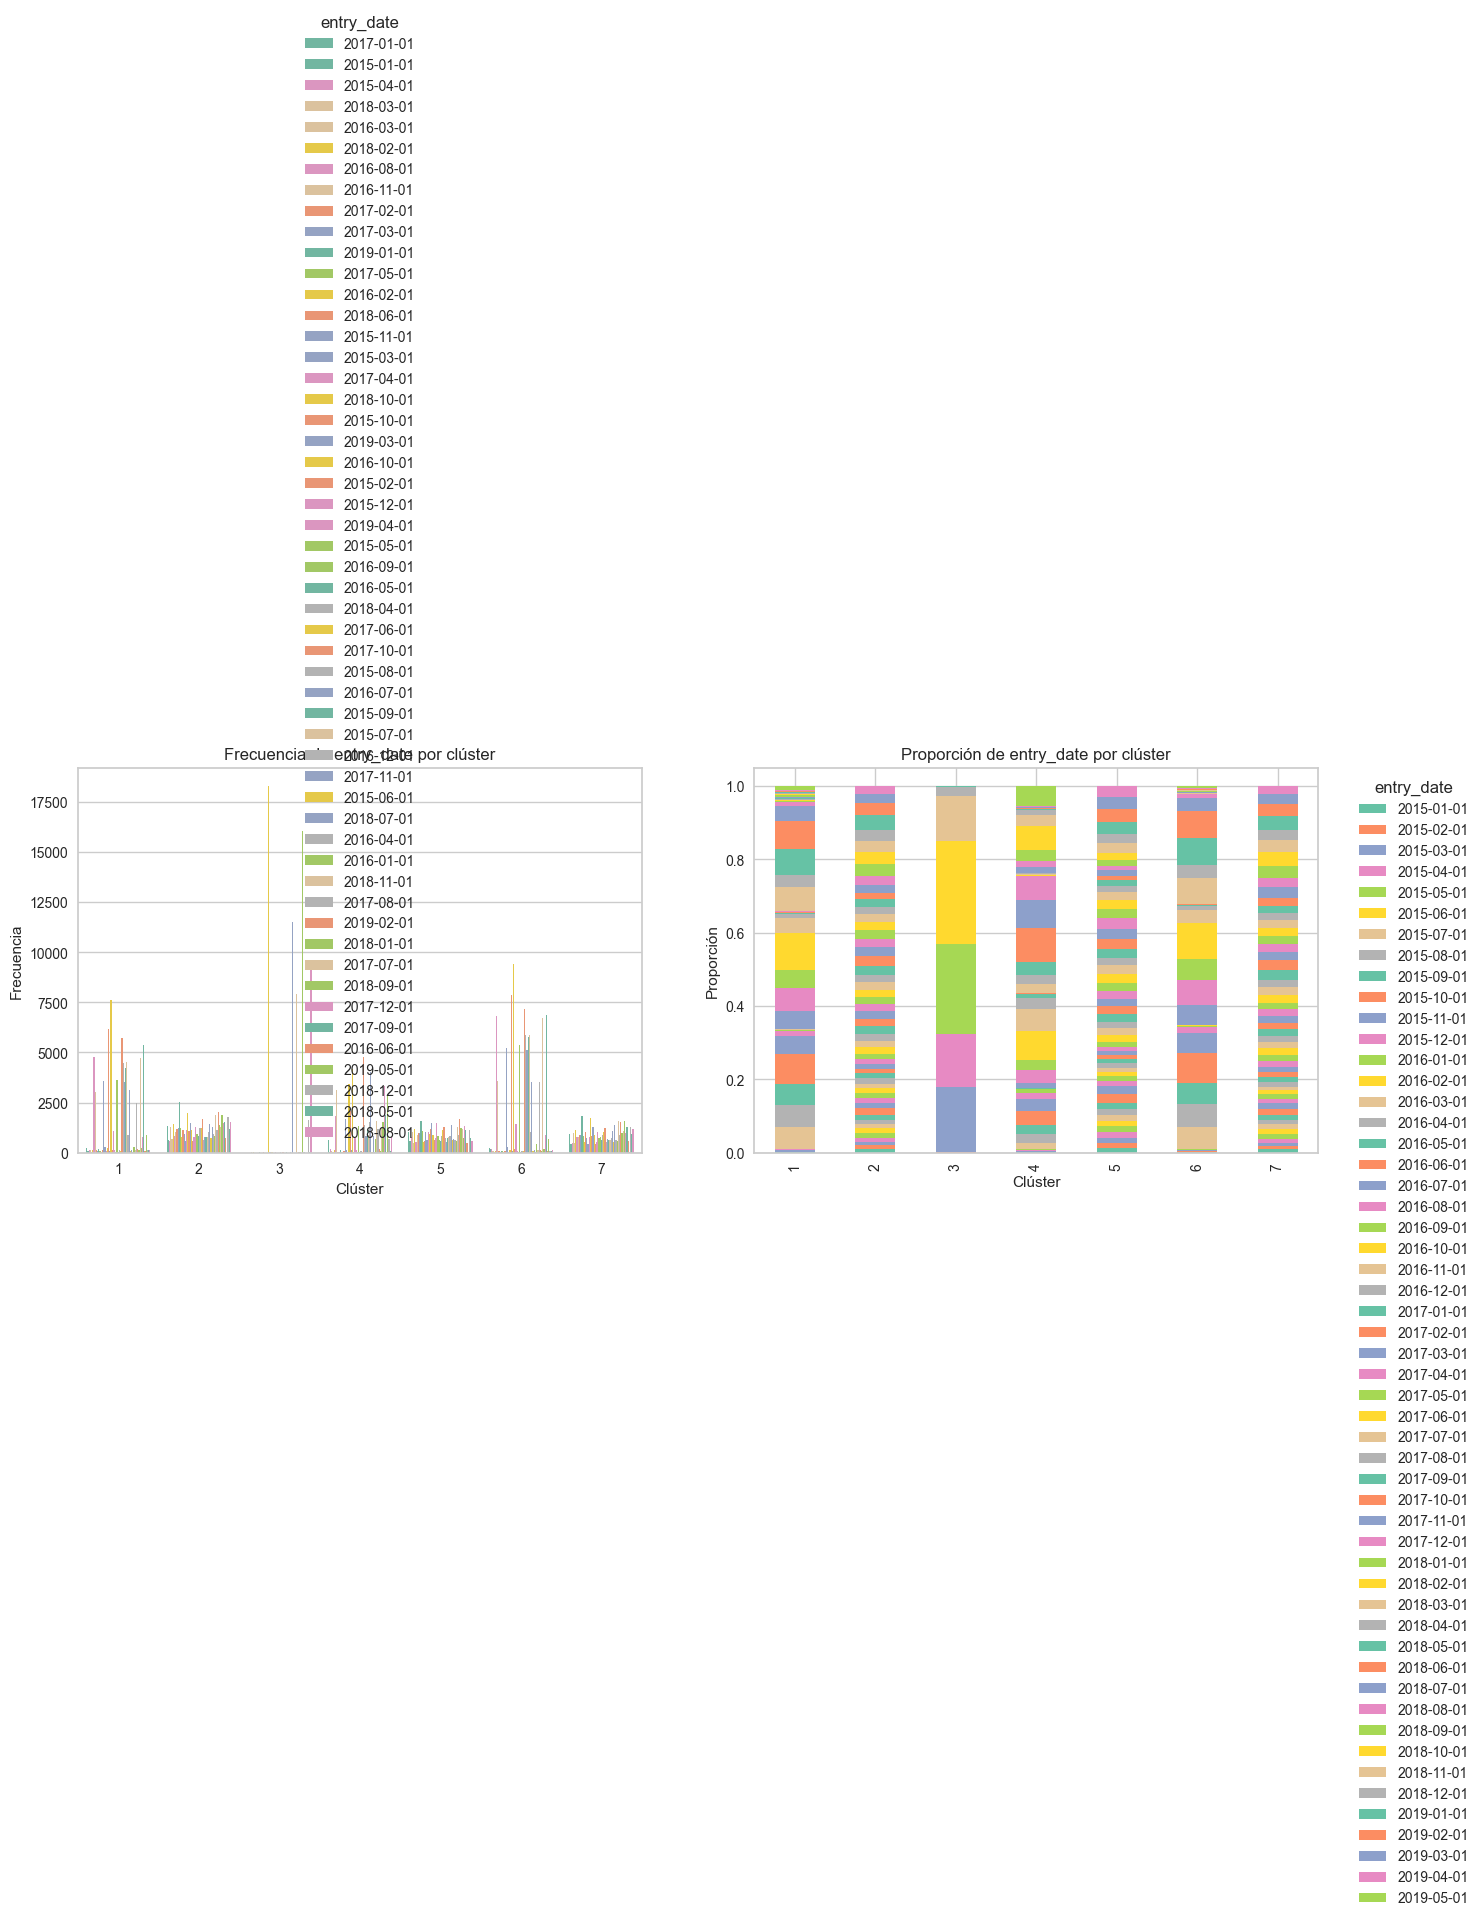

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/53717835.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


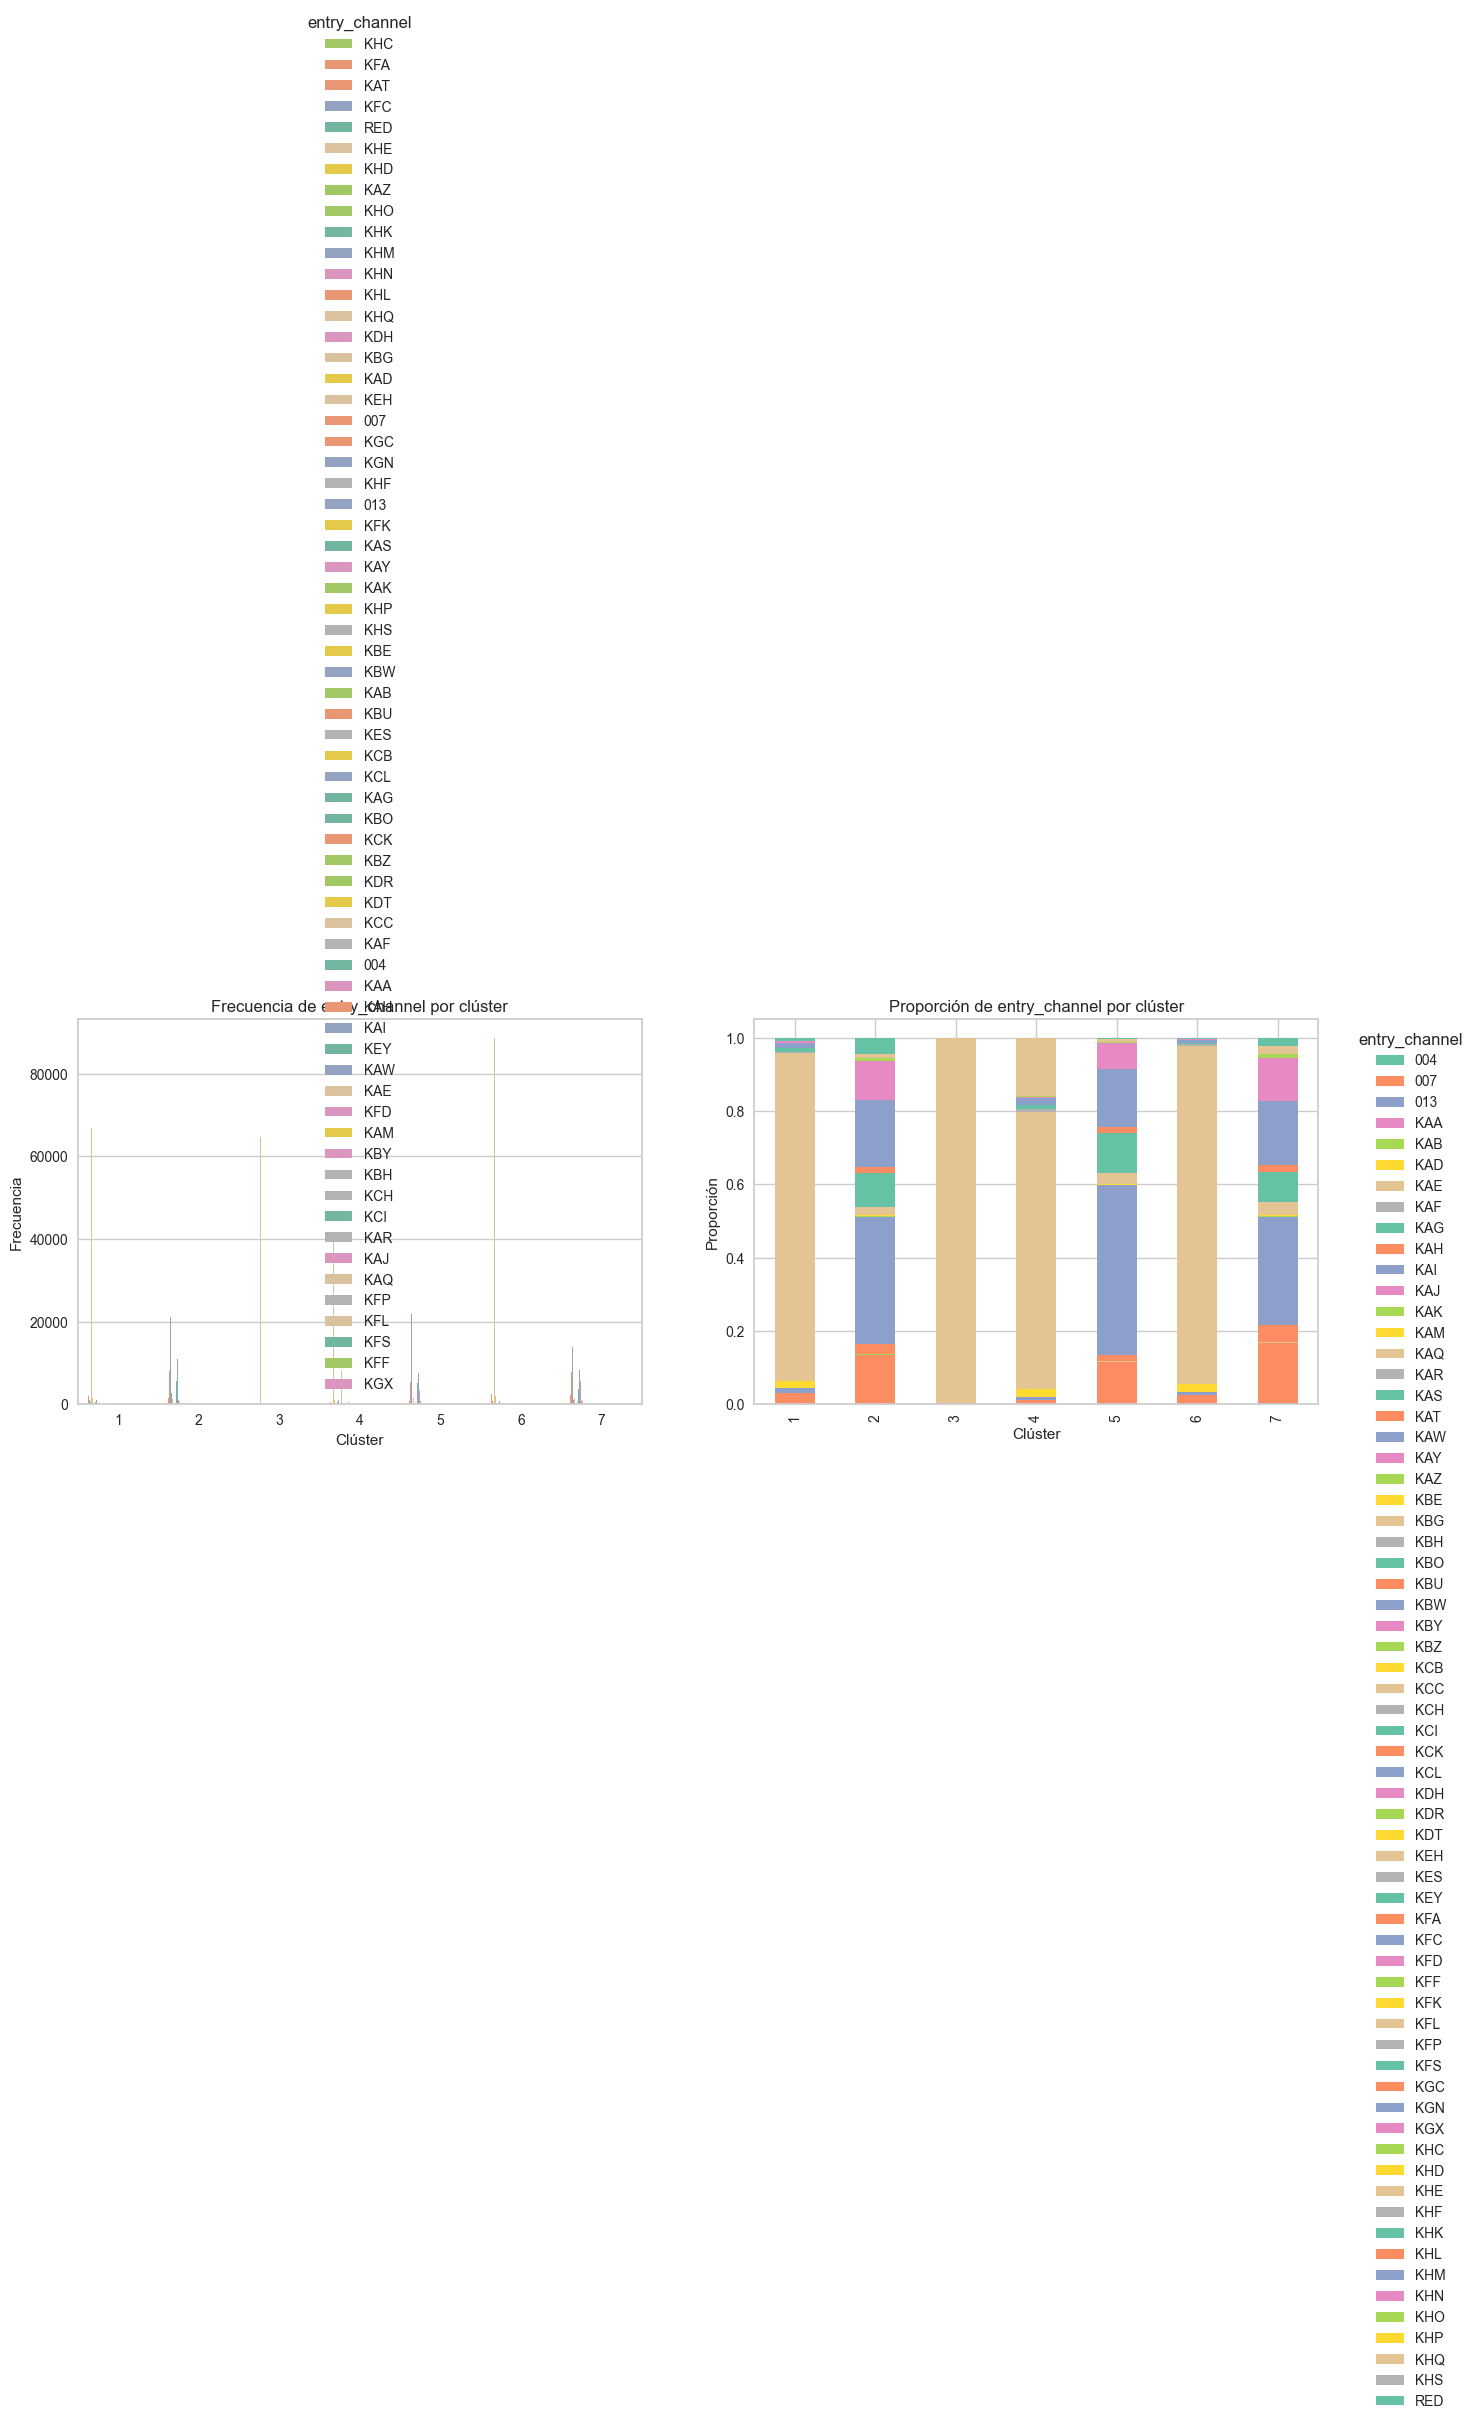

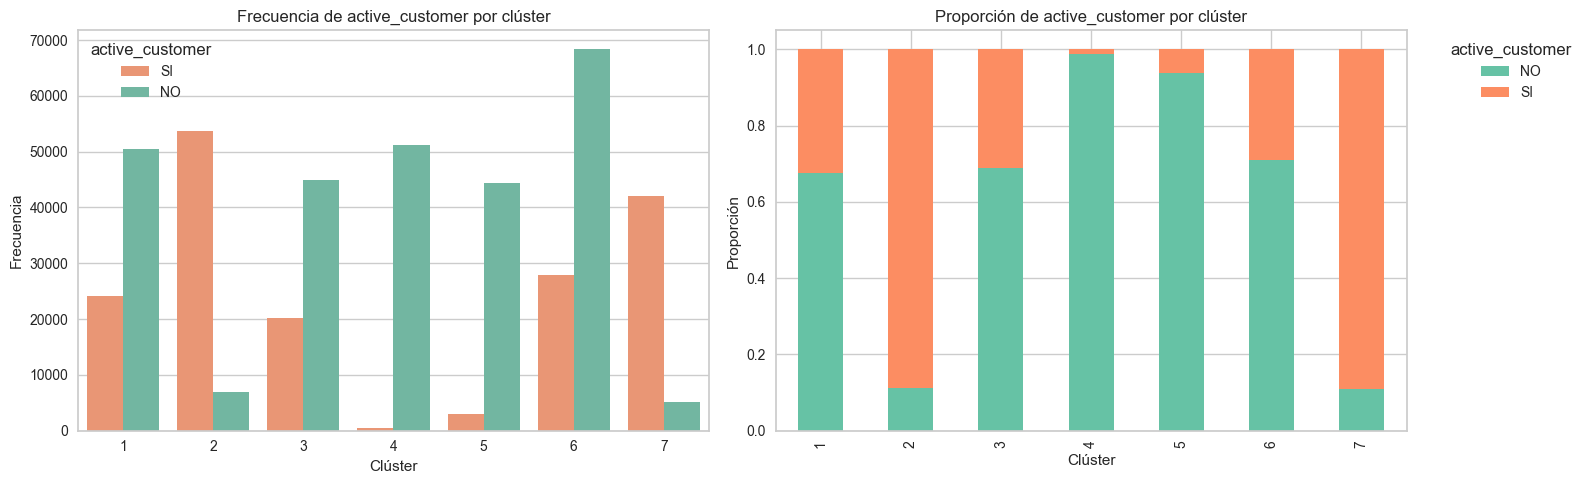

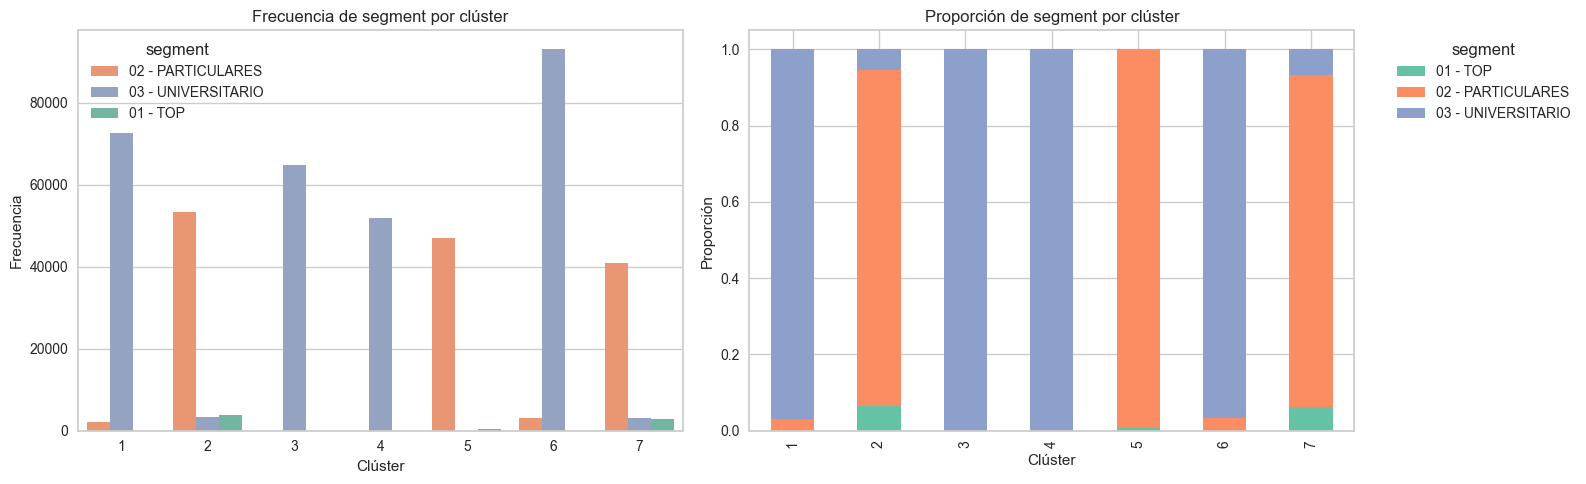

/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_15157/53717835.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


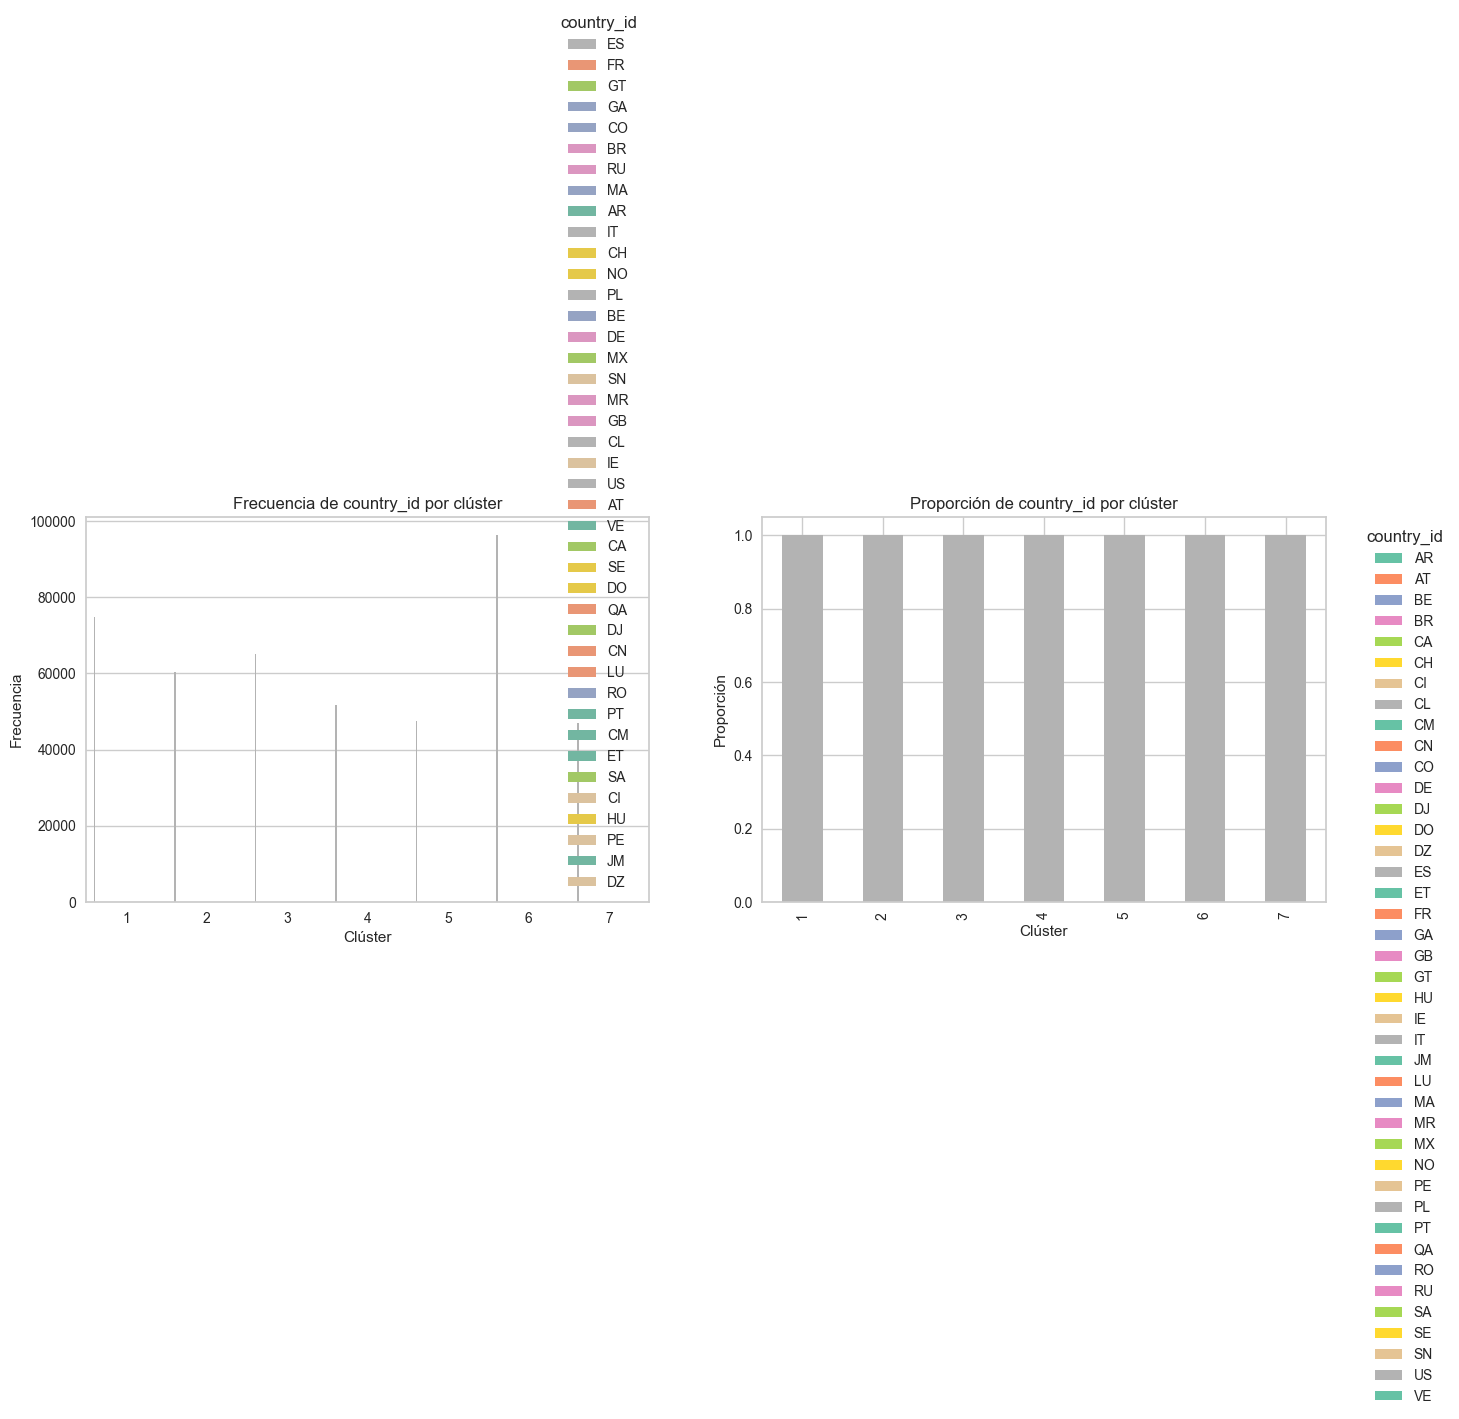

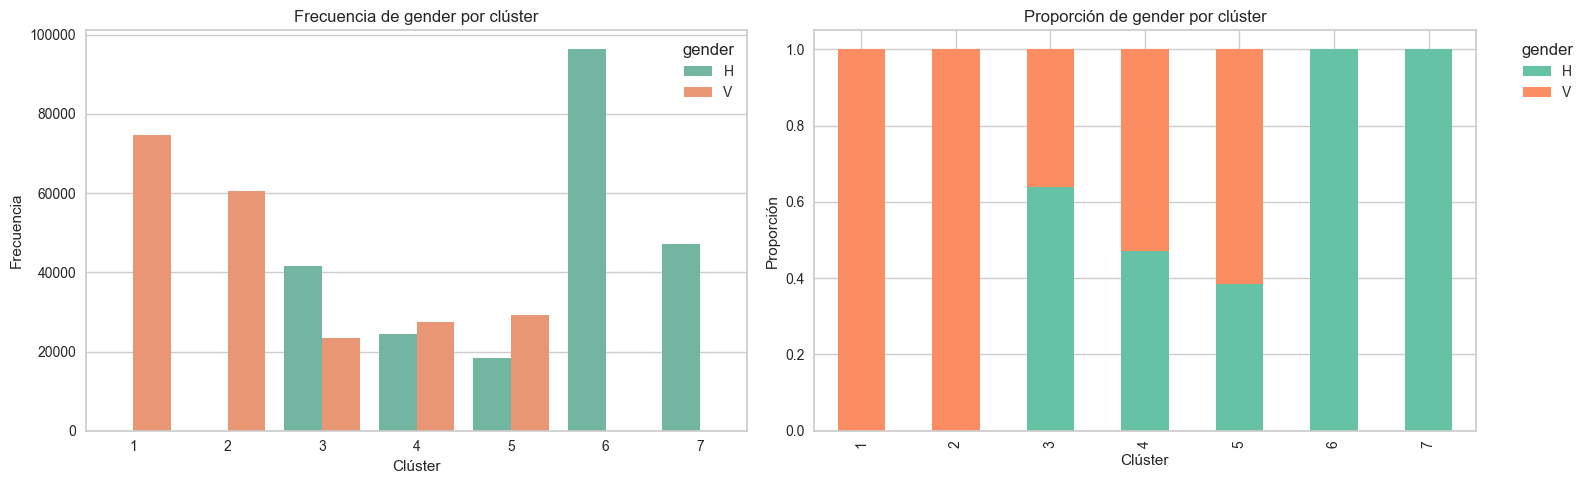

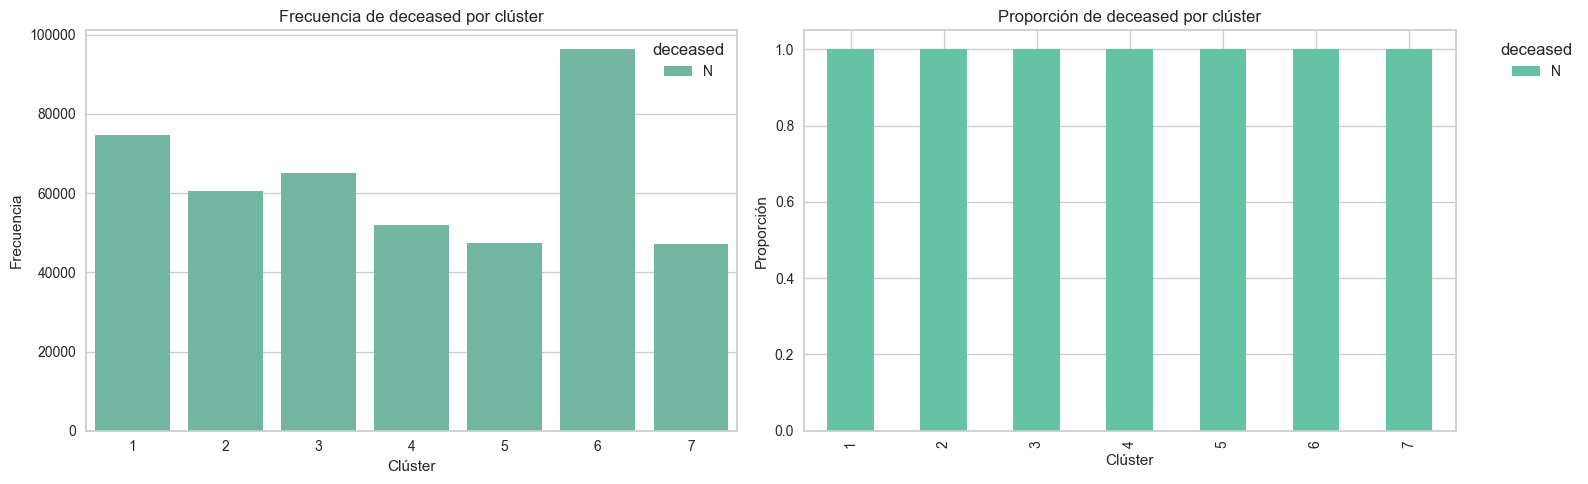

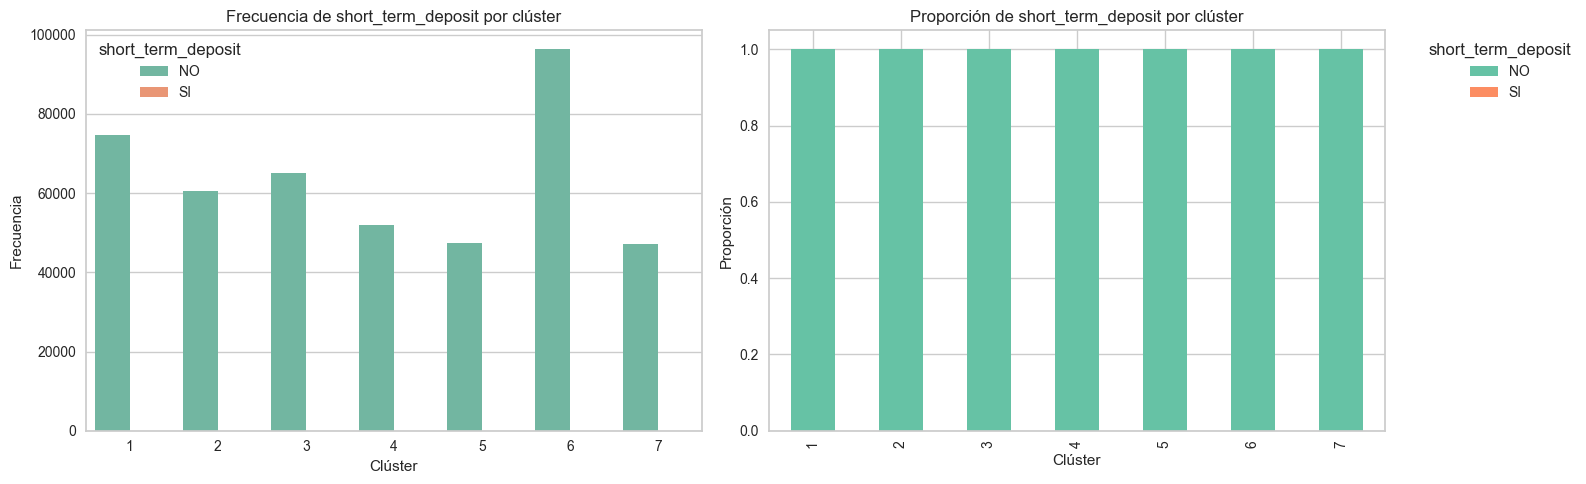

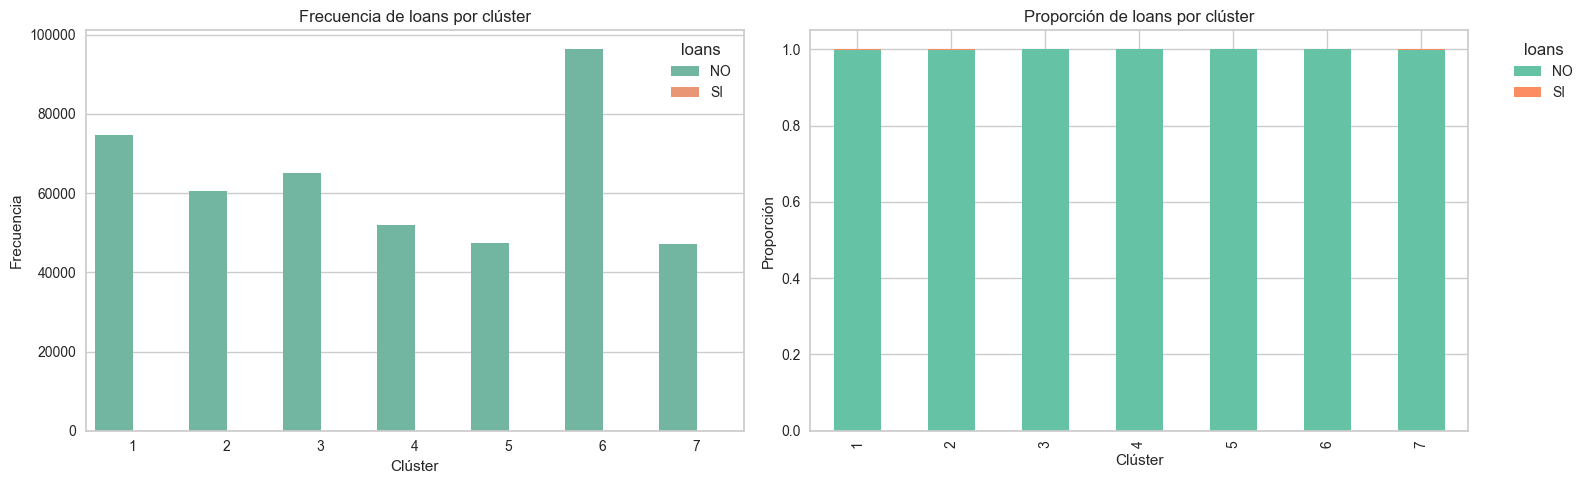

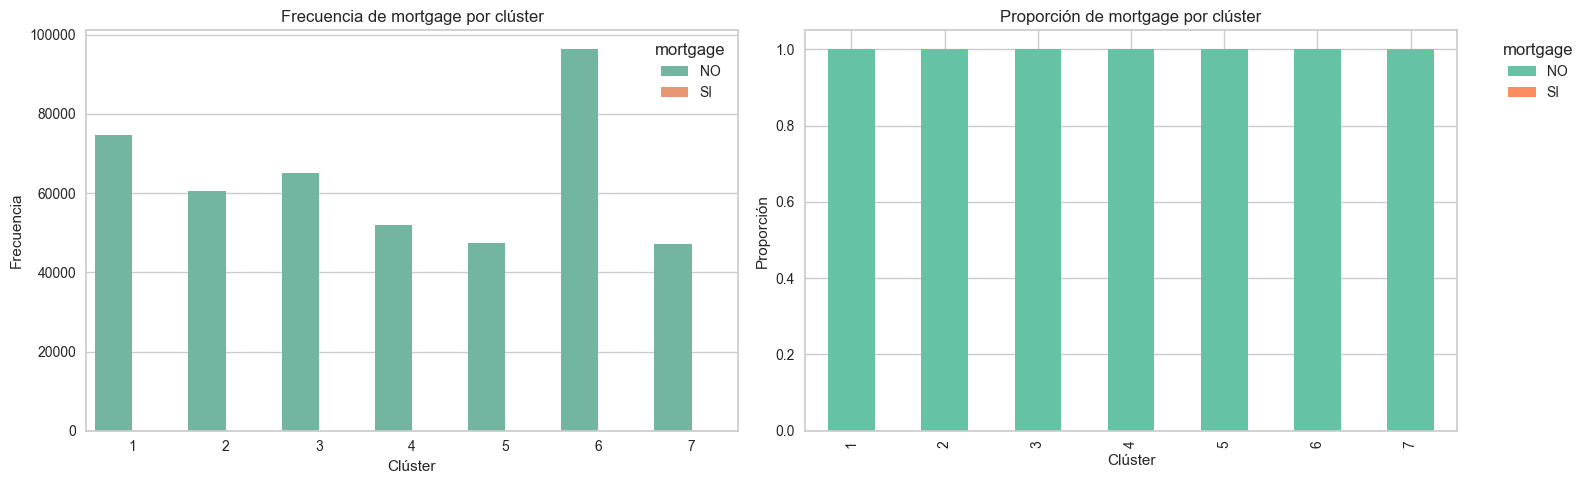

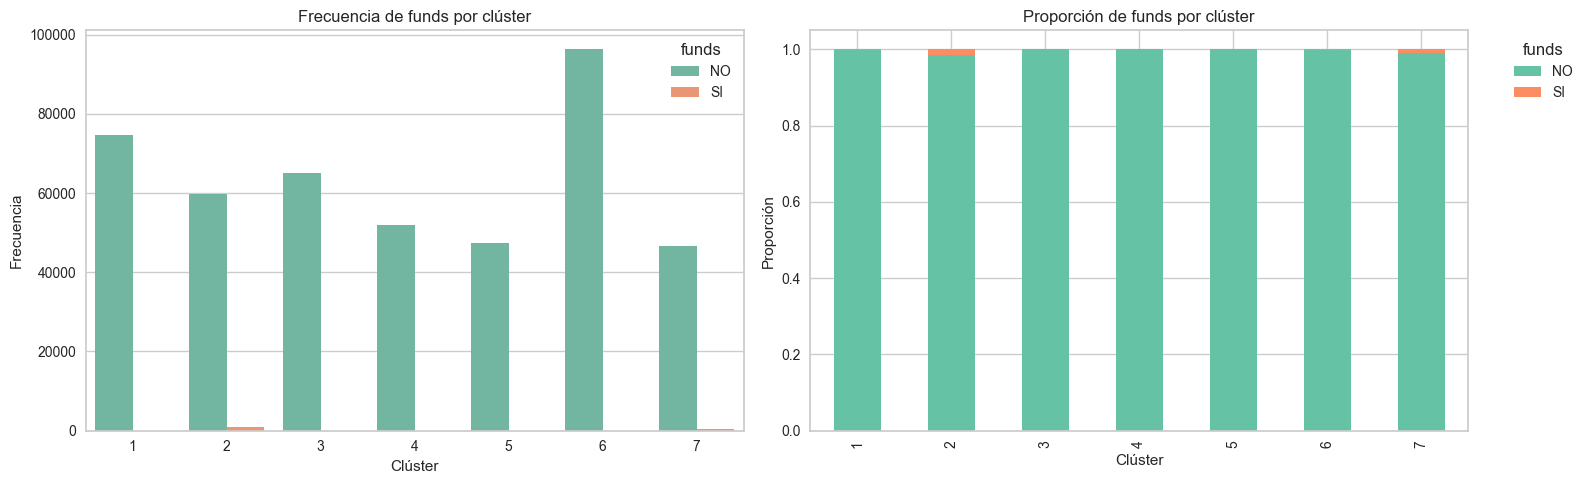

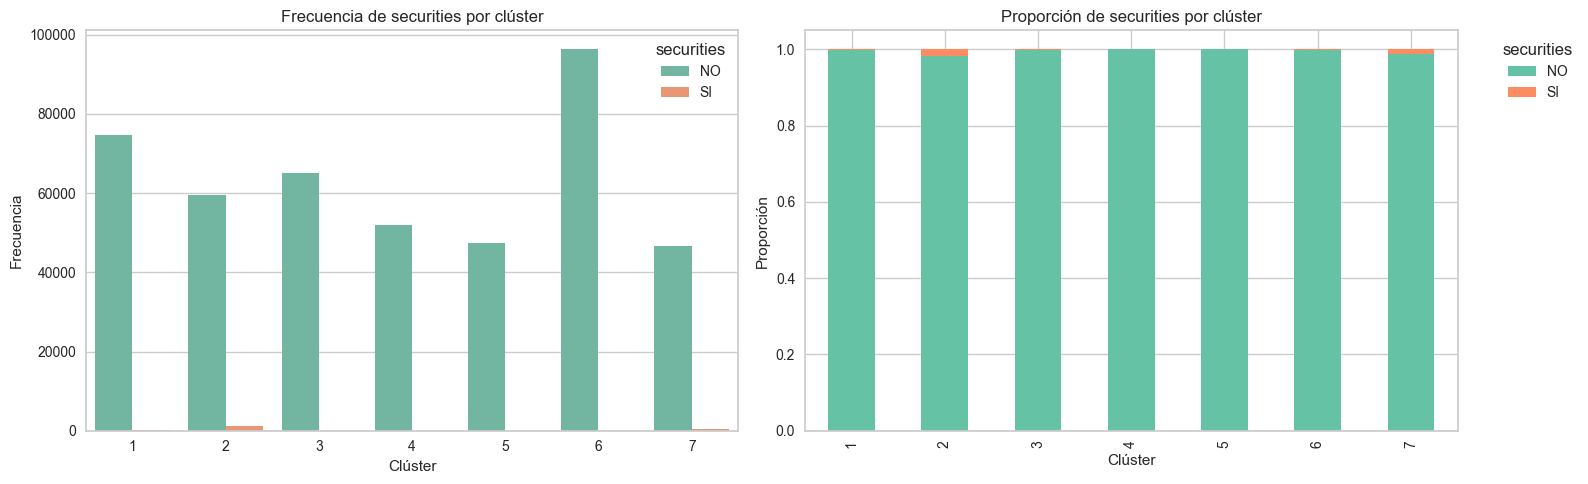

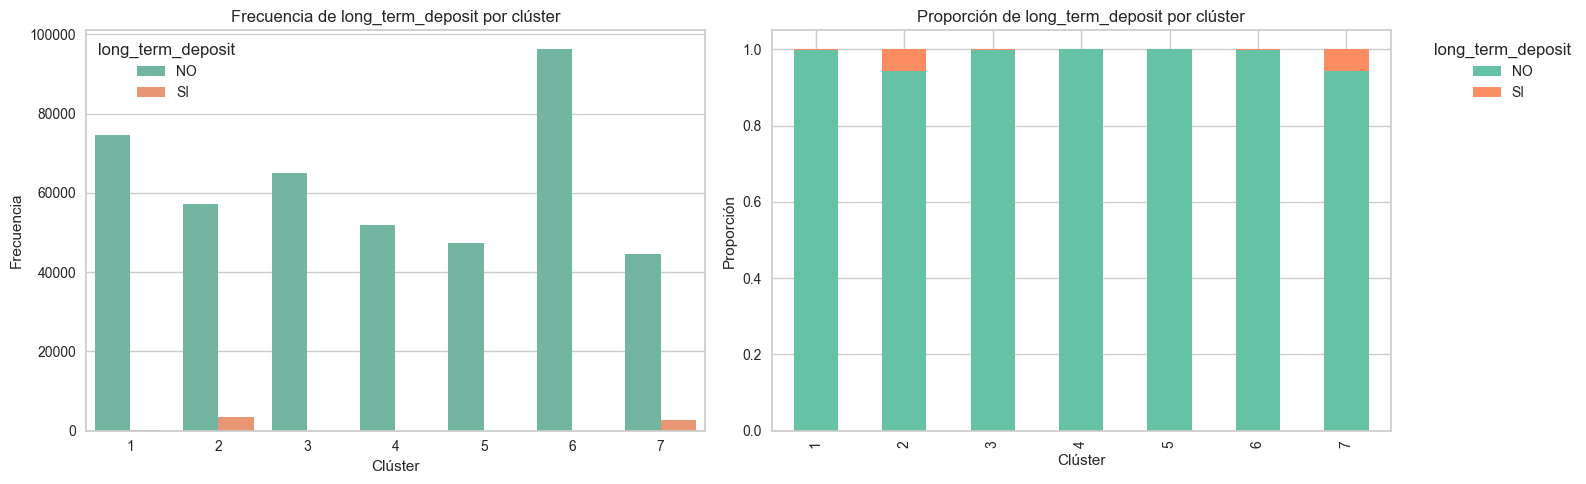

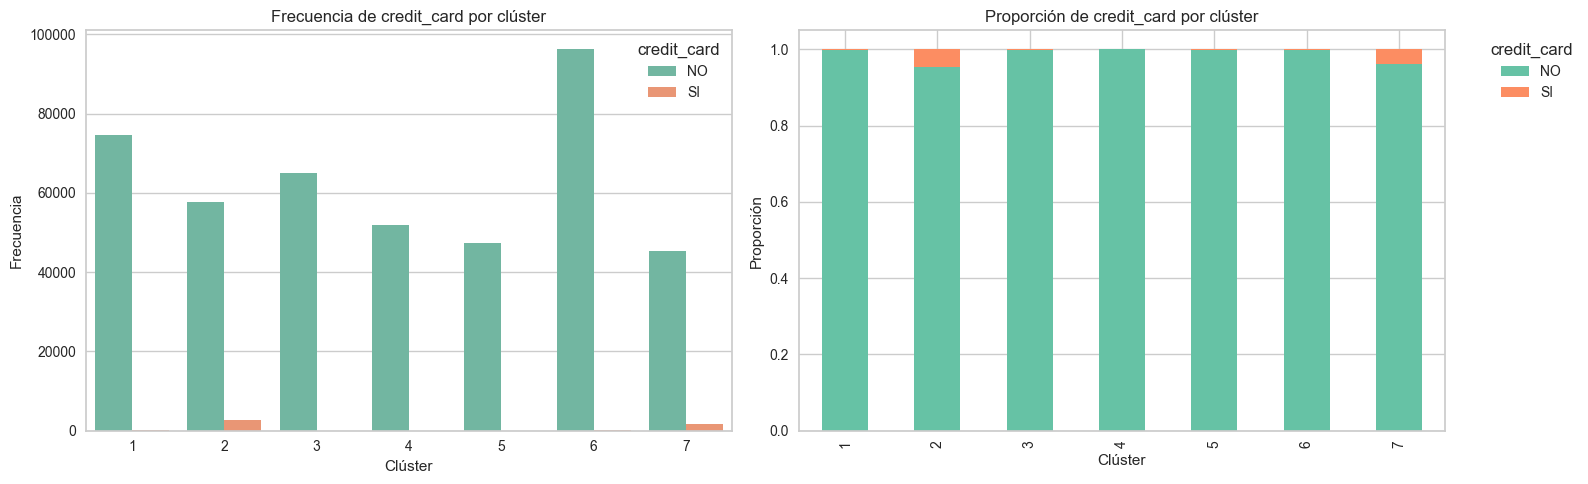

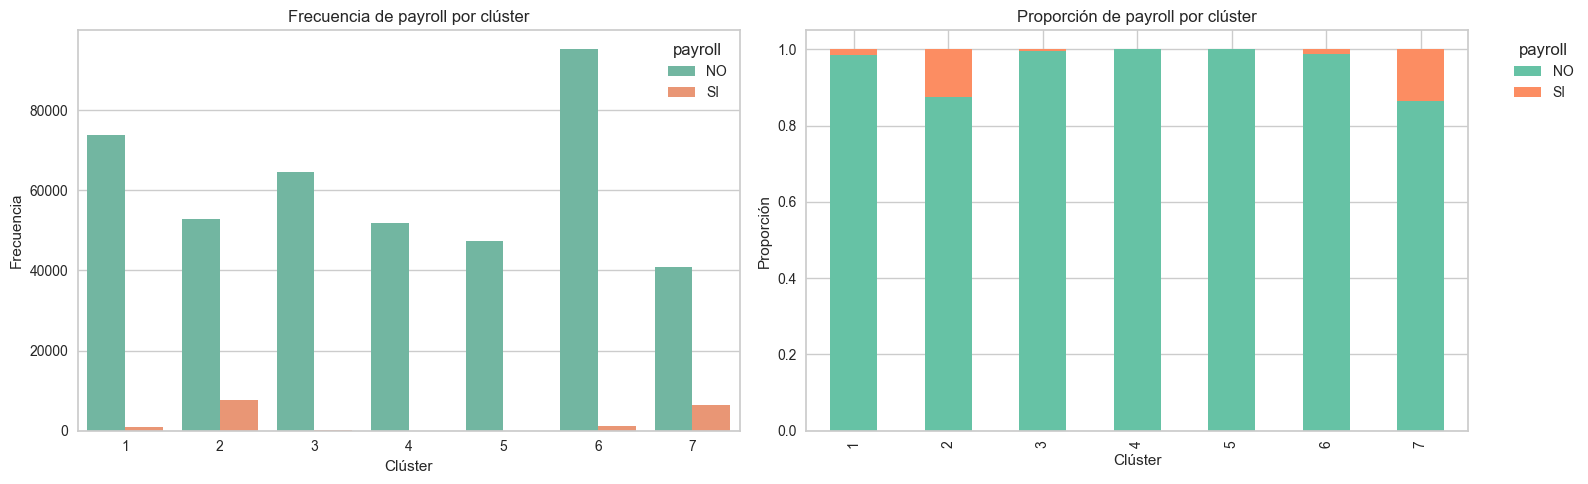

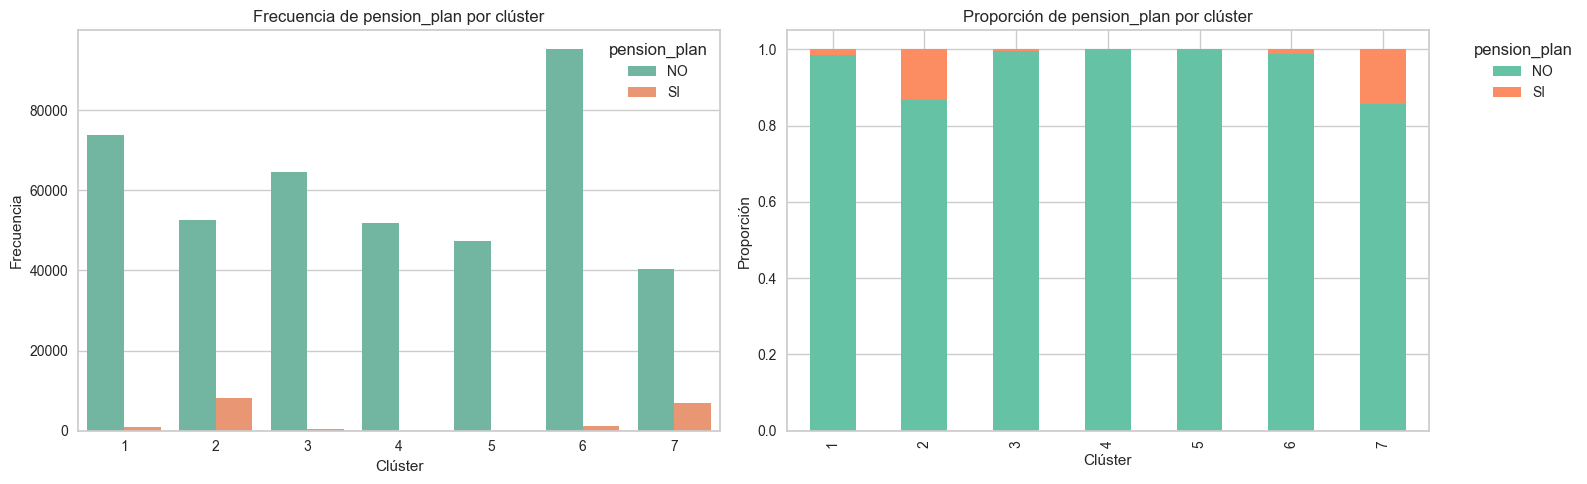

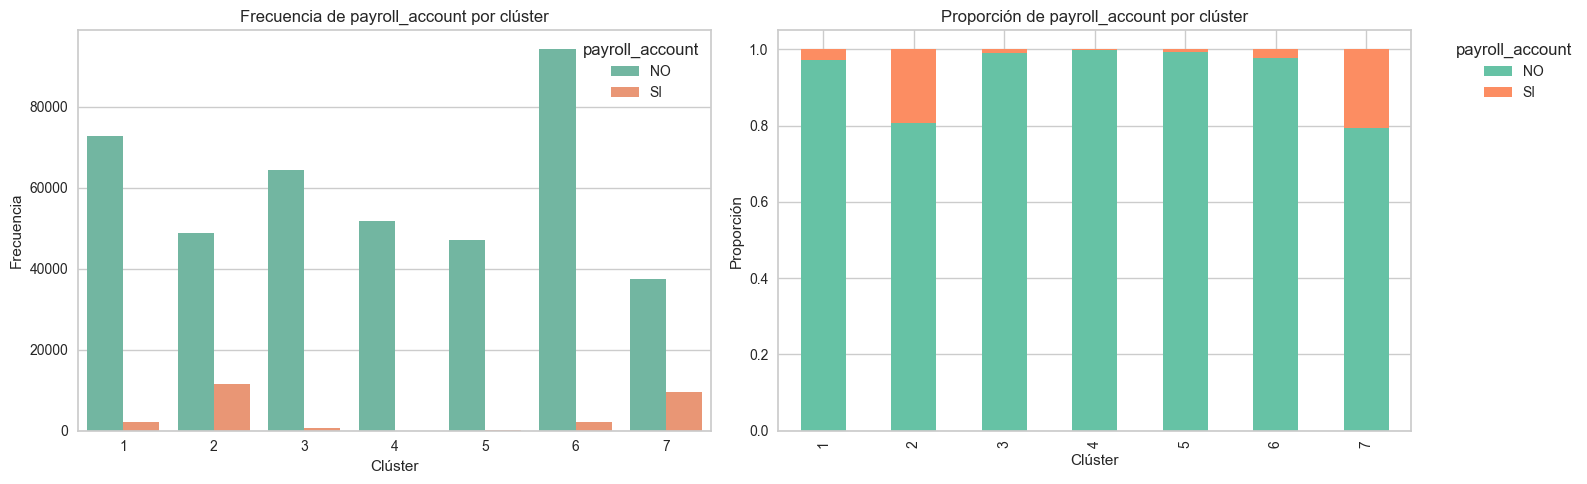

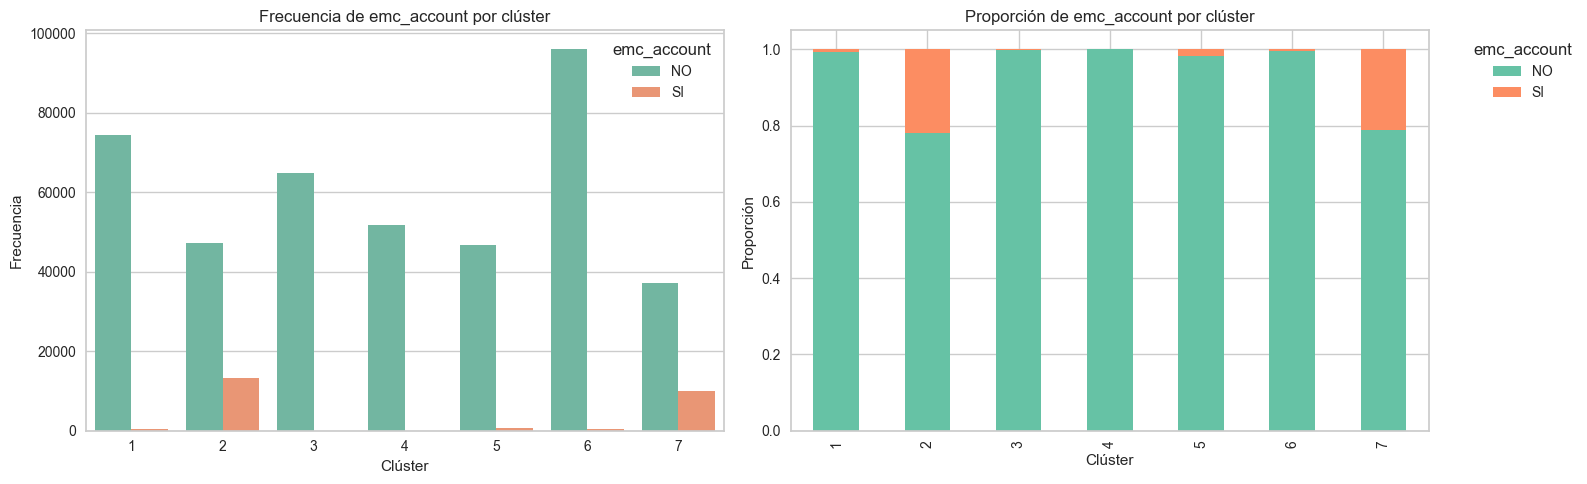

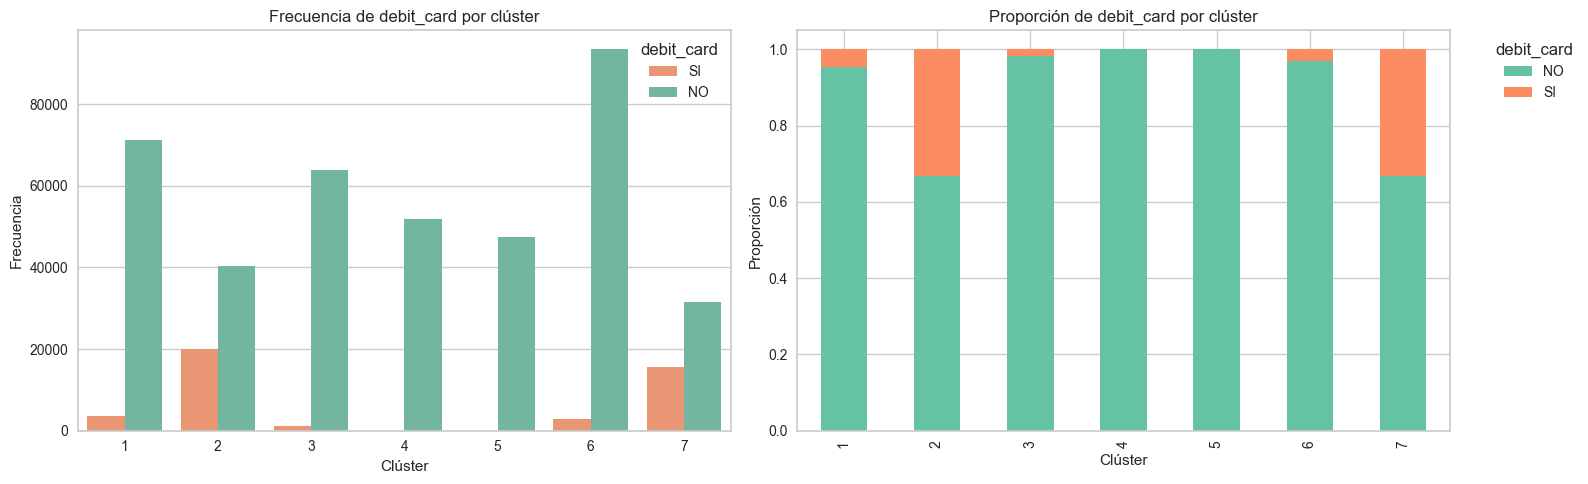

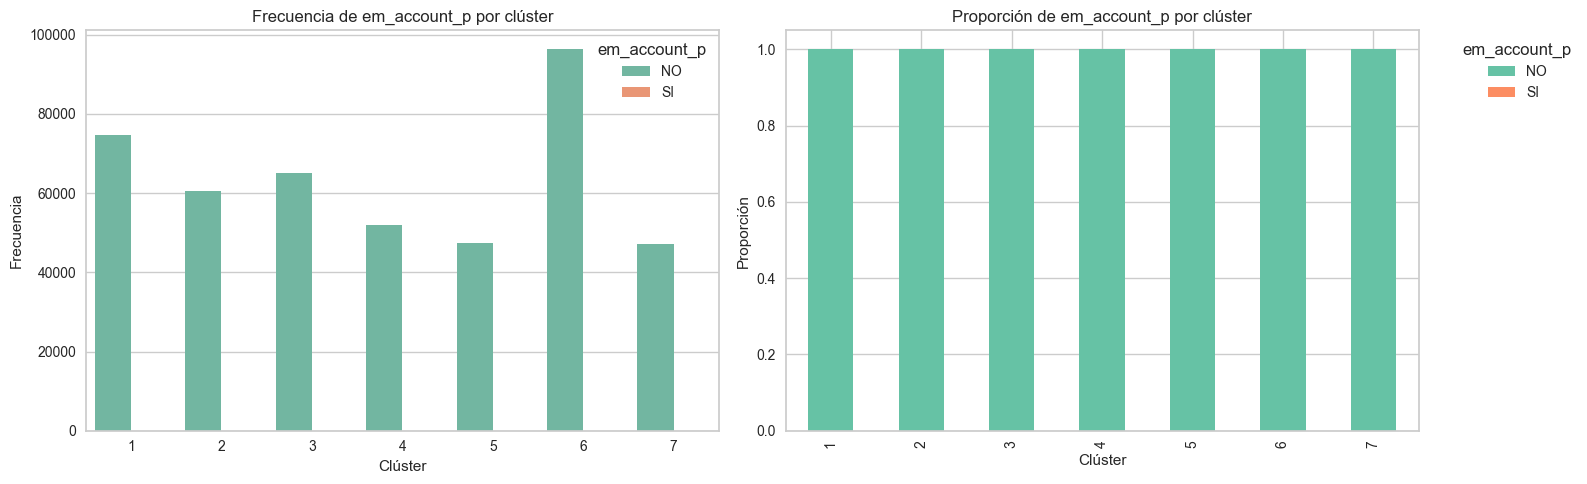

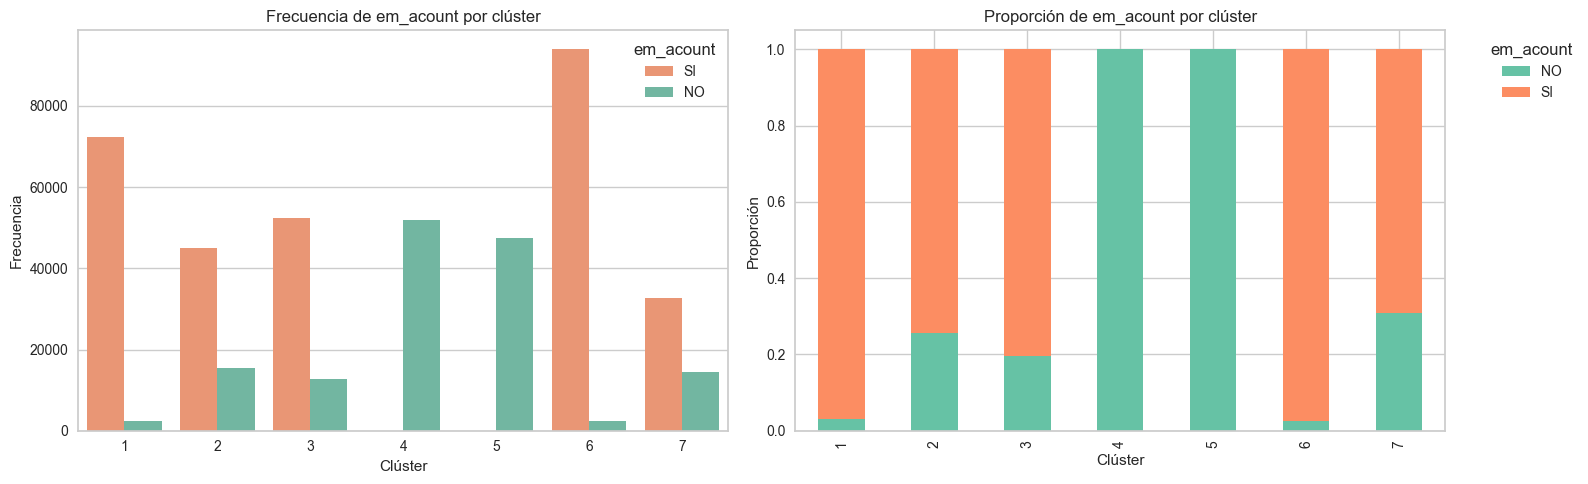

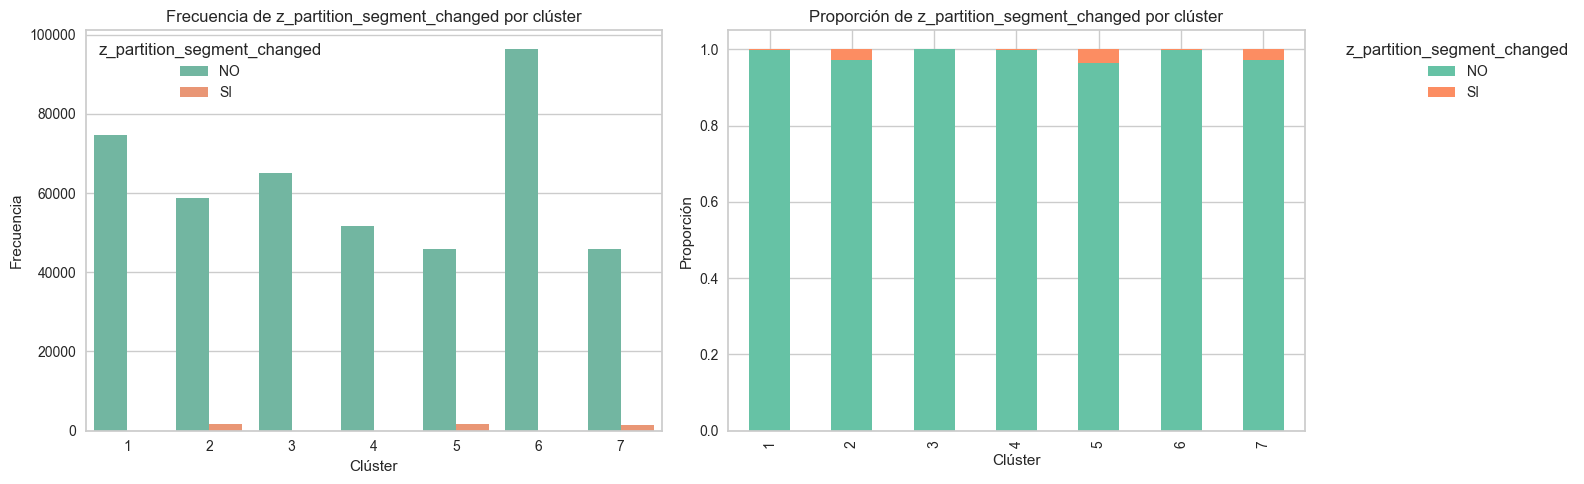

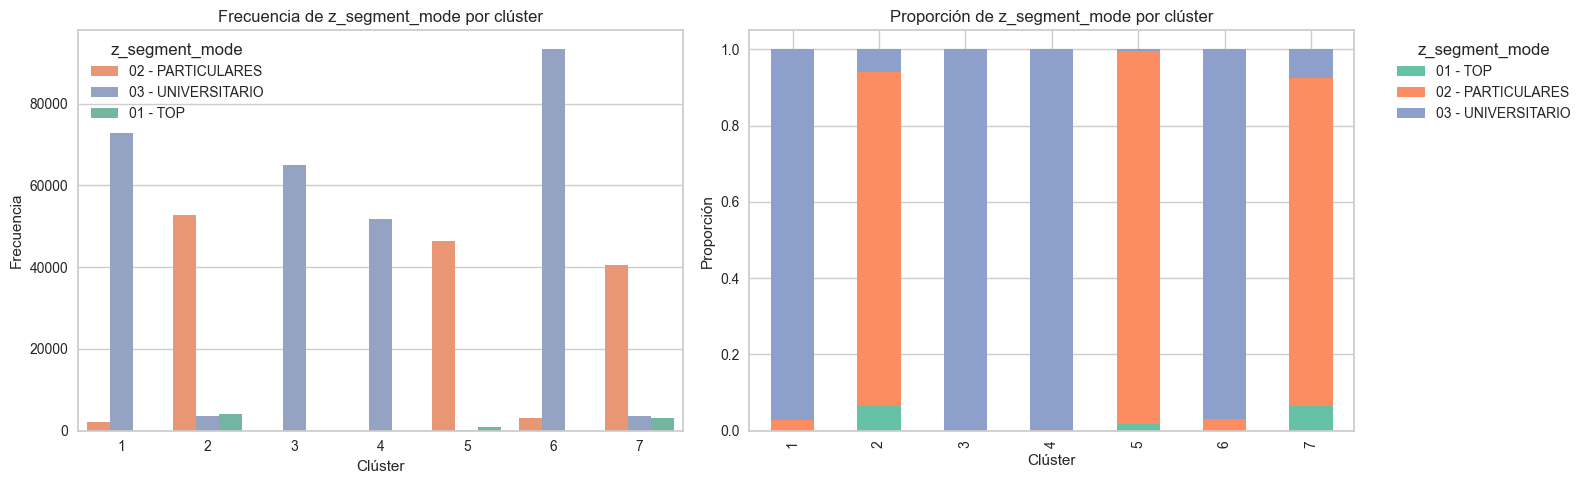

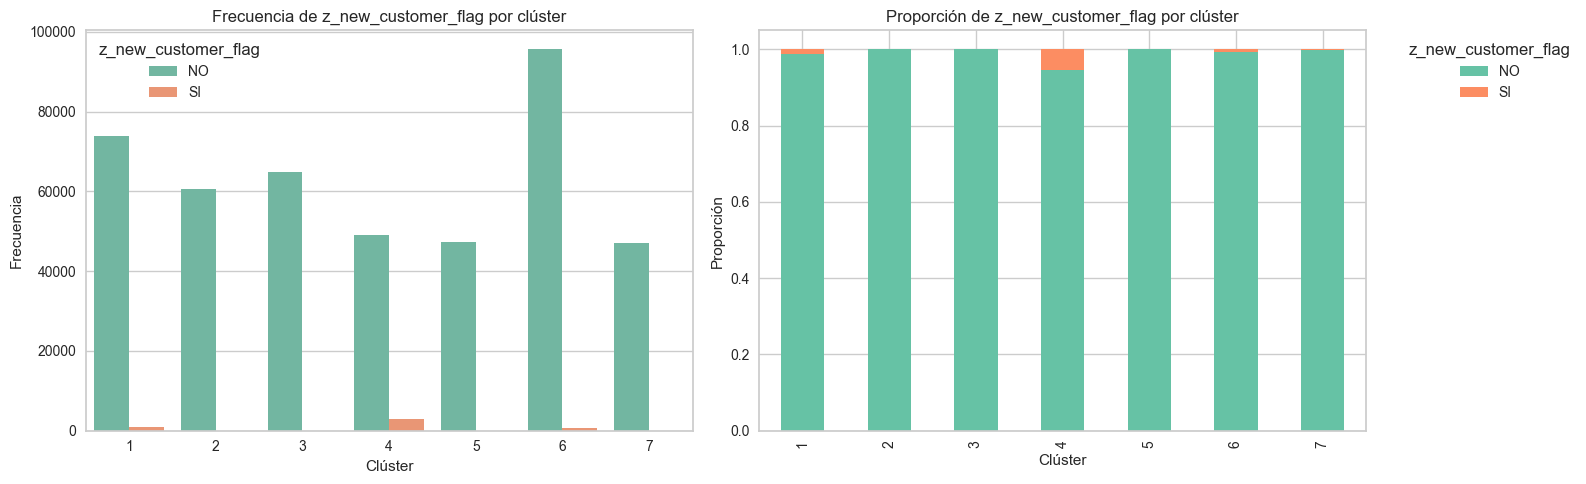

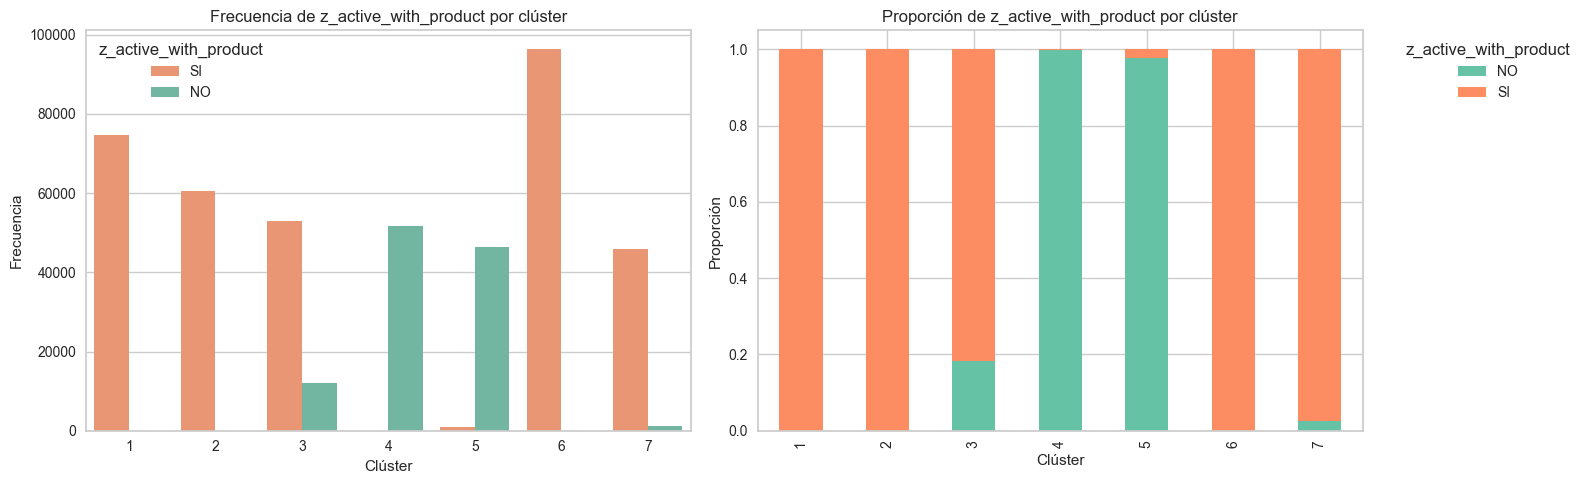

In [100]:
for col in categorical_features:
    unique_categories = df_merged[col].dropna().unique()
    unique_categories.sort()  # para que el orden sea consistente

    palette = sns.color_palette("Set2", len(unique_categories))
    color_dict = dict(zip(unique_categories, palette))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Gráfico de frecuencias (countplot) con colores fijos
    sns.countplot(data=df_merged, x="cluster", hue=col, palette=color_dict, ax=axes[0])
    axes[0].set_title(f"Frecuencia de {col} por clúster")
    axes[0].set_xlabel("Clúster")
    axes[0].set_ylabel("Frecuencia")
    
    # Tabla de proporciones
    freq_table = pd.crosstab(df_merged["cluster"], df_merged[col], normalize="index")
    freq_table = freq_table[unique_categories]

    freq_table.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color=[color_dict[cat] for cat in unique_categories]
    )
    axes[1].set_title(f"Proporción de {col} por clúster")
    axes[1].set_xlabel("Clúster")
    axes[1].set_ylabel("Proporción")
    axes[1].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()